# "The Price of Exclusion: Quantifying the Socioeconomic Impact of Immigrant Women's Labor Marginalization"

**This notebook explores how the exclusion of immigrant women from the U.S. workforce affects economic growth, social mobility, and policy outcomes.**

**Core Concept:** Examining how systems of power, policy, and social norms intersect to structually exclude immigrant women from full participation in the labor market and what that exclusion costs us all.

**Research Question:** How do structural inequalities rooted in immigration and labor policy produce the economic and social exclusion of immigrant women, and what are the consequences of that exclusion across race, class, and nationality?


In [ ]:
##libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load and Preview The Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 2023-IPUMS-USA-Data-csv.gz to 2023-IPUMS-USA-Data-csv.gz


## 2. Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv("2023-IPUMS-USA-Data-csv.gz", sep=",")
df = df.copy()
df.head()


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,...,IND,LOOKING,AVAILBLE,WRKRECAL,INCTOT,FTOTINC,INCWAGE,POVERTY,MIGRATE1,MIGRATE1D
0,2023,202301,1,2023010000113,6.0,2023000000011,280201,3,1,6.0,...,0,3,5,3,11500,9999999,0,0,1,10
1,2023,202301,2,2023010000180,27.0,2023000000021,10001,3,1,27.0,...,0,3,5,3,0,9999999,0,0,1,10
2,2023,202301,3,2023010000181,47.0,2023000000031,40201,4,1,47.0,...,0,3,5,3,0,9999999,0,0,1,10
3,2023,202301,4,2023010000250,11.0,2023000000041,270201,3,1,11.0,...,0,0,0,0,9999999,9999999,999999,0,2,23
4,2023,202301,5,2023010000340,57.0,2023000000051,280201,4,1,57.0,...,4971,1,5,3,2500,9999999,2500,0,3,32


In [ ]:
df.tail()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,...,IND,LOOKING,AVAILBLE,WRKRECAL,INCTOT,FTOTINC,INCWAGE,POVERTY,MIGRATE1,MIGRATE1D
3405804,2023,202301,1519008,2023001457972,77.0,2023015190081,30056,1,1,78.0,...,7860,3,5,3,80000,145000,80000,501,1,10
3405805,2023,202301,1519008,2023001457972,77.0,2023015190081,30056,1,2,62.0,...,7860,1,5,3,65000,145000,0,501,1,10
3405806,2023,202301,1519009,2023001458196,75.0,2023015190091,20056,1,1,76.0,...,8191,3,5,3,75000,75000,75000,482,1,10
3405807,2023,202301,1519010,2023001459187,37.0,2023015190101,10056,1,1,37.0,...,0,1,5,3,23000,43600,0,218,1,10
3405808,2023,202301,1519010,2023001459187,37.0,2023015190101,10056,1,2,44.0,...,0,1,5,3,20600,43600,0,218,1,10


In [ ]:
df.shape

(3405809, 53)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3405809 entries, 0 to 3405808
Data columns (total 53 columns):
 #   Column     Dtype  
---  ------     -----  
 0   YEAR       int64  
 1   SAMPLE     int64  
 2   SERIAL     int64  
 3   CBSERIAL   int64  
 4   HHWT       float64
 5   CLUSTER    int64  
 6   STRATA     int64  
 7   GQ         int64  
 8   PERNUM     int64  
 9   PERWT      float64
 10  SEX        int64  
 11  AGE        int64  
 12  MARST      int64  
 13  RACE       int64  
 14  RACED      int64  
 15  HISPAN     int64  
 16  HISPAND    int64  
 17  BPL        int64  
 18  BPLD       int64  
 19  CITIZEN    int64  
 20  YRNATUR    int64  
 21  YRIMMIG    int64  
 22  YRSUSA1    int64  
 23  LANGUAGE   int64  
 24  LANGUAGED  int64  
 25  SPEAKENG   int64  
 26  RACAMIND   int64  
 27  RACASIAN   int64  
 28  RACBLK     int64  
 29  RACPACIS   int64  
 30  RACWHT     int64  
 31  RACOTHER   int64  
 32  SCHOOL     int64  
 33  EDUC       int64  
 34  EDUCD      int64  

In [ ]:
df.columns

Index(['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STRATA',
       'GQ', 'PERNUM', 'PERWT', 'SEX', 'AGE', 'MARST', 'RACE', 'RACED',
       'HISPAN', 'HISPAND', 'BPL', 'BPLD', 'CITIZEN', 'YRNATUR', 'YRIMMIG',
       'YRSUSA1', 'LANGUAGE', 'LANGUAGED', 'SPEAKENG', 'RACAMIND', 'RACASIAN',
       'RACBLK', 'RACPACIS', 'RACWHT', 'RACOTHER', 'SCHOOL', 'EDUC', 'EDUCD',
       'GRADEATT', 'GRADEATTD', 'EMPSTAT', 'EMPSTATD', 'LABFORCE', 'CLASSWKR',
       'CLASSWKRD', 'OCC', 'IND', 'LOOKING', 'AVAILBLE', 'WRKRECAL', 'INCTOT',
       'FTOTINC', 'INCWAGE', 'POVERTY', 'MIGRATE1', 'MIGRATE1D'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=3405809, step=1)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,3405809.0,2.023000e+03,0.000000e+00,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03,2.023000e+03
SAMPLE,3405809.0,2.023010e+05,0.000000e+00,2.023010e+05,2.023010e+05,2.023010e+05,2.023010e+05,2.023010e+05
SERIAL,3405809.0,7.589917e+05,4.414736e+05,1.000000e+00,3.723860e+05,7.568300e+05,1.147002e+06,1.519010e+06
CBSERIAL,3405809.0,2.023001e+12,2.111813e+06,2.023000e+12,2.023000e+12,2.023001e+12,2.023001e+12,2.023010e+12
HHWT,3405809.0,9.723818e+01,8.743515e+01,1.000000e+00,4.800000e+01,7.100000e+01,1.150000e+02,2.225000e+03
CLUSTER,3405809.0,2.023008e+12,4.414736e+06,2.023000e+12,2.023004e+12,2.023008e+12,2.023011e+12,2.023015e+12
STRATA,3405809.0,4.888102e+05,8.443947e+05,1.000100e+04,1.000050e+05,2.312480e+05,4.801480e+05,8.100351e+06
GQ,3405809.0,1.134287e+00,5.784842e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
PERNUM,3405809.0,2.057684e+00,1.331731e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01
PERWT,3405809.0,9.833637e+01,8.923316e+01,1.000000e+00,4.700000e+01,7.200000e+01,1.170000e+02,2.225000e+03


In [ ]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,3405809,2023,0,2023,2023,2023,2023,2023
SAMPLE,3405809,202301,0,202301,202301,202301,202301,202301
SERIAL,3405809,758992,441474,1,372386,756830,1147002,1519010
CBSERIAL,3405809,2023001213511,2111813,2023000000001,2023000384958,2023000769938,2023001154557,2023010177025
HHWT,3405809,97,87,1,48,71,115,2225
CLUSTER,3405809,2023007589918,4414736,2023000000011,2023003723861,2023007568301,2023011470021,2023015190101
STRATA,3405809,488810,844395,10001,100005,231248,480148,8100351
GQ,3405809,1,1,1,1,1,1,5
PERNUM,3405809,2,1,1,1,2,3,20
PERWT,3405809,98,89,1,47,72,117,2225


In [ ]:
## After I described the data, I realized some problematic values like irrelevant '0' or '9999'=> review the key of the data and:

#df['SEX'] = df['SEX'].replace({1: 'Male', 2: 'Female', 9: 'Missing/blank'})
#df["MARST"] = df["MARST"].replace({1: 'Married, spouse present', 2: 'Married, spouse absent', 3: ' Separated', 4: 'Divorced', 5: 'Widowed', 6: 'Never married/single', 9: 'Blank, missing'})
#df['RACE'] = df['RACE'].replace({1: 'White', 2:'Black/African American', 3:'American Indian or Alaska Native', 4:'Chinese', 5:'Japanese', 6:'Other Asian or Pacific Islander', 7:'Other race, nec', 8:'Two major races', 9:'Three or more major races'})
#df['HISPAN']= df['HISPAN'].replace({0: 'Not Hispanic', 1: 'Mexican', 2: 'Puerto Rican', 3: 'Cuban', 4: 'Other', 9:'Not Reported'})
#df['CITIZEN'] = df['CITIZEN'].replace({0:'N/A',1: 'Born abroad of American parents', 2: 'Naturalized citizen', 3:'Not a citizen', 4:'Not a citizen, but has received first papers', 5:'Foreign born, citizenship status not reported',8:'Illegible',9:'Missing/blank' })
#df['EDUC'] = df['EDUC'].replace({0: 'N/A or no schooling', 1:'Nursery school to grade 4', 2:'Grade 5, 6, 7, or 8', 3:'Grade 9', 4:'Grade 10', 5:'Grade 11', 6:'Grade 12', 7:'1 year of college', 8:'2 years of college', 9:'3 years of college', 10:'4 years of college', 11:'5+ years of college', 99:'Missing'})
#df['EMPSTAT'] = df['EMPSTAT'].replace({0:'N/A',1: 'Male', 2: 'Female'})


## SEX


In [ ]:
## SEX ##

df['SEX'] = df['SEX'].replace({1: 'Male', 2: 'Female', 9: 'Missing/blank'})

##find the sex
df['SEX'].value_counts()


,count
SEX,
Female,1733894
Male,1671915


In [ ]:
## Pie Chart

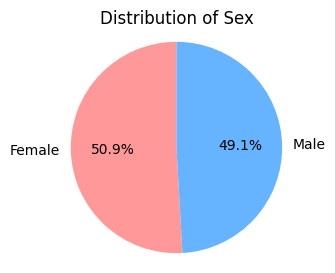

In [ ]:
import matplotlib.pyplot as plt

labels = ['Female', 'Male']
counts = [1733894, 1671915]

plt.figure(figsize=(3,3))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Sex')
plt.axis('equal')  # Equal aspect ratio makes the pie chart circular.
plt.show()


##AGE##

In [ ]:
df[(df["AGE"]>16) & (df["AGE"]<65)]



,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STRATA,GQ,PERNUM,PERWT,...,IND,LOOKING,AVAILBLE,WRKRECAL,INCTOT,FTOTINC,INCWAGE,POVERTY,MIGRATE1,MIGRATE1D
1,2023,202301,2,2023010000180,27,2023000000021,10001,3,1,27,...,0,3,5,3,0,9999999,0,0,1,10
2,2023,202301,3,2023010000181,47,2023000000031,40201,4,1,47,...,0,3,5,3,0,9999999,0,0,1,10
4,2023,202301,5,2023010000340,57,2023000000051,280201,4,1,57,...,4971,1,5,3,2500,9999999,2500,0,3,32
5,2023,202301,6,2023010000364,52,2023000000061,120201,4,1,52,...,7860,1,5,3,500,9999999,500,0,1,10
6,2023,202301,7,2023010000493,43,2023000000071,180101,3,1,43,...,3570,3,5,3,0,9999999,0,0,2,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3405802,2023,202301,1519007,2023001456541,125,2023015190071,50056,1,3,69,...,8680,3,5,3,13400,13400,13400,86,1,10
3405803,2023,202301,1519007,2023001456541,125,2023015190071,50056,1,4,68,...,9480,3,5,3,6000,6000,6000,39,1,10
3405804,2023,202301,1519008,2023001457972,77,2023015190081,30056,1,1,78,...,7860,3,5,3,80000,145000,80000,501,1,10
3405806,2023,202301,1519009,2023001458196,75,2023015190091,20056,1,1,76,...,8191,3,5,3,75000,75000,75000,482,1,10


In [ ]:
df['AGE'].value_counts()

,count
AGE,
65,51074
62,51043
63,50732
64,50528
66,50283
...,...
90,4790
95,4637
92,4566


In [ ]:
# Age groups----Genereal
bins = [0, 15, 24, 34, 44, 54, 64, 74, 84, 120]
labels = ['0–15', '16–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75–84', '85+']

df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)

# how many people in age groups
age_group_counts = df['AGE_GROUP'].value_counts().sort_index()
print(age_group_counts)


AGE_GROUP
0–15     528696
16–24    368978
25–34    401969
35–44    412631
45–54    400838
55–64    475002
65–74    452259
75–84    250569
85+       85399
Name: count, dtype: int64


In [ ]:
# Age groups-----in labor force
bins = [15, 24, 54, 64, 120]
labels = ['16–24', '25–54', '55–64', '65+']

df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)

# how many people in age groups
age_group_counts = df['AGE_GROUP'].value_counts().sort_index()
print(age_group_counts)

AGE_GROUP
16–24     368978
25–54    1215438
55–64     475002
65+       788227
Name: count, dtype: int64


In [ ]:
# Step 1: Filter data for women aged between 16 and 65
filtered_df = df[(df["AGE"] >= 16) & (df["AGE"] <= 65) & (df["SEX"] == "Female")]

# Step 2: Create age groups
bins = [15, 24, 54, 64, 120]
labels = ['16–24', '25–54', '55–64', '65+']
filtered_df['AGE_GROUP'] = pd.cut(filtered_df['AGE'], bins=bins, labels=labels, right=True)

# Step 3: Group by Age Group, Race, and Sex
result = filtered_df.groupby(['AGE_GROUP', 'RACE', 'SEX']).size().reset_index(name='Count')

# Step 4: Display the result
print(result)


   AGE_GROUP  RACE     SEX   Count
0      16–24     1  Female  105870
1      16–24     2  Female   17783
2      16–24     3  Female    2753
3      16–24     4  Female    3248
4      16–24     5  Female     245
5      16–24     6  Female    9173
6      16–24     7  Female   13827
7      16–24     8  Female   24201
8      16–24     9  Female    2281
9      25–54     1  Female  379828
10     25–54     2  Female   52851
11     25–54     3  Female    8189
12     25–54     4  Female   11959
13     25–54     5  Female    1706
14     25–54     6  Female   36917
15     25–54     7  Female   41875
16     25–54     8  Female   66823
17     25–54     9  Female    4769
18     55–64     1  Female  174855
19     55–64     2  Female   22913
20     55–64     3  Female    2826
21     55–64     4  Female    4030
22     55–64     5  Female     838
23     55–64     6  Female    9695
24     55–64     7  Female   10683
25     55–64     8  Female   20284
26     55–64     9  Female    1089
27       65+     1  

/tmp/ipython-input-338191438.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['AGE_GROUP'] = pd.cut(filtered_df['AGE'], bins=bins, labels=labels, right=True)
/tmp/ipython-input-338191438.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = filtered_df.groupby(['AGE_GROUP', 'RACE', 'SEX']).size().reset_index(name='Count')


In [ ]:
print(df.columns.tolist())

['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STRATA', 'GQ', 'PERNUM', 'PERWT', 'SEX', 'AGE', 'MARST', 'RACE', 'RACED', 'HISPAN', 'HISPAND', 'BPL', 'BPLD', 'CITIZEN', 'YRNATUR', 'YRIMMIG', 'YRSUSA1', 'LANGUAGE', 'LANGUAGED', 'SPEAKENG', 'RACAMIND', 'RACASIAN', 'RACBLK', 'RACPACIS', 'RACWHT', 'RACOTHER', 'SCHOOL', 'EDUC', 'EDUCD', 'GRADEATT', 'GRADEATTD', 'EMPSTAT', 'EMPSTATD', 'LABFORCE', 'CLASSWKR', 'CLASSWKRD', 'OCC', 'IND', 'LOOKING', 'AVAILBLE', 'WRKRECAL', 'INCTOT', 'FTOTINC', 'INCWAGE', 'POVERTY', 'MIGRATE1', 'MIGRATE1D', 'AGE_GROUP']


In [ ]:
df.columns = df.columns.str.strip()

## **MARITAL STATUS**

In [ ]:
## MARST ## Marital Status ##
df["MARST"] = df["MARST"].replace({1: 'Married, spouse present', 2: 'Married, spouse absent', 3: ' Separated', 4: 'Divorced', 5: 'Widowed', 6: 'Never married/single', 9: 'Blank, missing'})
df["MARST"].value_counts()

#marst_counts = df['MARST'].value_counts()
#display(marst_counts.head(20))

,count
MARST,
Never married/single,1402238
"Married, spouse present",1402160
Divorced,305308
Widowed,189328
"Married, spouse absent",65848
Separated,40927


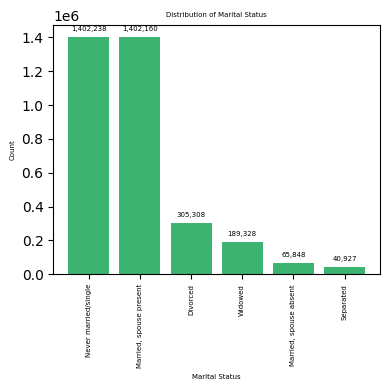

In [ ]:
import matplotlib.pyplot as plt

# Data
statuses = [
    'Never married/single',
    'Married, spouse present',
    'Divorced',
    'Widowed',
    'Married, spouse absent',
    'Separated'
]

counts = [
    1402238,
    1402160,
    305308,
    189328,
    65848,
    40927
]

# Plot
plt.figure(figsize=(4, 4))
bars = plt.bar(statuses, counts, color='mediumseagreen')
plt.xlabel("Marital Status", fontsize=5)
plt.ylabel("Count", fontsize=5)
plt.title("Distribution of Marital Status", fontsize=5)
plt.xticks(rotation=90, ha='center', fontsize=5)
plt.tight_layout()

# Optional: Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 30000, f'{height:,}', ha='center', va='bottom', fontsize=5)

plt.show()


## **RACE**

In [ ]:
## RACE ##

df['RACE'] = df['RACE'].replace({1: 'White', 2:'Black/African American', 3:'American Indian or Alaska Native', 4:'Chinese', 5:'Japanese', 6:'Other Asian or Pacific Islander', 7:'Other race, nec', 8:'Two major races', 9:'Three or more major races'})
df['RACE'].value_counts()


,count
RACE,
White,2273916
Two major races,355732
Black/African American,295055
"Other race, nec",196480
Other Asian or Pacific Islander,153429
Chinese,51180
American Indian or Alaska Native,43601
Three or more major races,27937
Japanese,8479


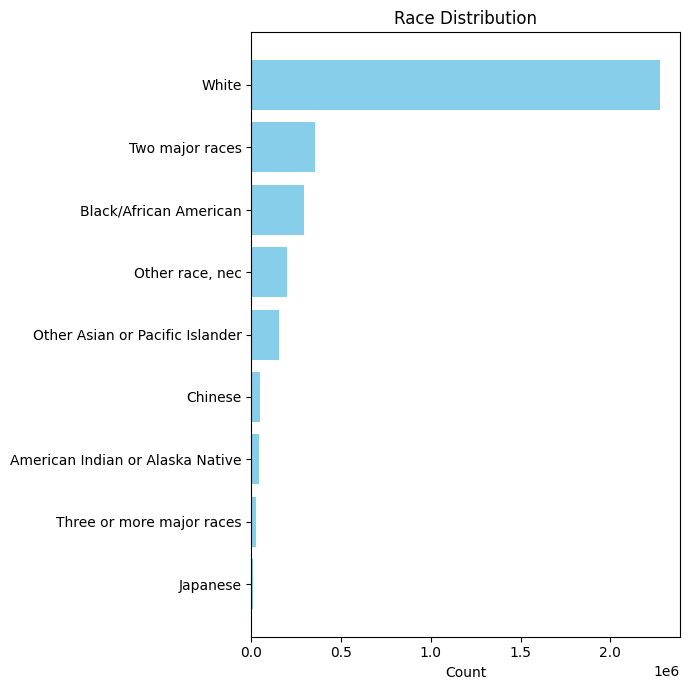

In [ ]:
import matplotlib.pyplot as plt

# Data
races = [
    'White',
    'Two major races',
    'Black/African American',
    'Other race, nec',
    'Other Asian or Pacific Islander',
    'Chinese',
    'American Indian or Alaska Native',
    'Three or more major races',
    'Japanese'
]

counts = [
    2273916,
    355732,
    295055,
    196480,
    153429,
    51180,
    43601,
    27937,
    8479
]

# Plot
plt.figure(figsize=(7, 7))
plt.barh(races, counts, color='skyblue')
plt.xlabel("Count")
plt.title("Race Distribution")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()


In [ ]:
## Maping Dictionary:

# 1. RACED               Race [detailed version]
                    #ONE MAJOR RACE GROUP

raced_code_map = {
    100: "White",
    110: "Spanish write-in",
    120: "Blank (white) (1850)",
    130: "Portuguese",
    140: "Mexican (1930)",
    150: "Puerto Rican (1910 Hawaii)",
    200: "Black/African American",
    210: "Mulatto",
    300: "American Indian/Alaska Native",
    302: "Apache",
    303: "Blackfoot",
    304: "Cherokee",
    305: "Cheyenne",
    306: "Chickasaw",
    307: "Chippewa",
    308: "Choctaw",
    309: "Comanche",
    310: "Creek",
    311: "Crow",
    312: "Iroquois",
    313: "Kiowa",
    314: "Lumbee",
    315: "Navajo",
    316: "Osage",
    317: "Paiute",
    318: "Pima",
    319: "Potawatomi",
    320: "Pueblo",
    321: "Seminole",
    322: "Shoshone",
    323: "Sioux",
    324: "Tlingit (Tlingit_Haida, 2000/ACS)",
    325: "Tohono O Odham",
    326: "All other tribes (1990)",
    328: "Hopi",
    329: "Central American Indian",
    330: "Spanish American Indian",
    340: "Aztec",
    341: "Inca",
    342: "Maya",
    343: "Mixtec",
    344: "Taino",
    345: "Tarasco (Purepecha)",
    350: "Delaware",
    351: "Latin American Indian",
    352: "Puget Sound Salish",
    353: "Yakama",
    354: "Yaqui",
    355: "Colville",
    356: "Houma",
    357: "Menominee",
    358: "Yuman",
    359: "South American Indian",
    360: "Mexican American Indian",
    361: "Other Amer. Indian tribe (2000,ACS)",
    362: "2+ Amer. Indian tribes (2000,ACS)",
    363: "American Indian alone, not specified",
    364: "All other Latin American Indian alone",
    370: "Alaskan Athabaskan",
    371: "Aleut",
    372: "Eskimo",
    373: "Alaskan mixed",
    374: "Inupiat",
    375: "Yup'ik",
    379: "Other Alaska Native tribe(s) (2000,ACS)",
    380: "Alaska Native alone, not specified",
    381: "Alaska Native tribes and villages alone",
    398: "Both Am. Ind. and Alaska Native (2000,ACS)",
    399: "Tribe not specified",
    400: "Chinese",
    410: "Taiwanese",
    420: "Chinese and Taiwanese",
    500: "Japanese",
    600: "Filipino",
    610: "Asian Indian (Hindu 1920_1940)",
    620: "Korean",
    630: "Hawaiian",
    631: 'Hawaiian and Asian (1900,1920)',
    632: 'Hawaiian and European (1900,1920)',
    634: 'Hawaiian mixed',
    640: 'Vietnamese',
    641: 'Bhutanese',
    642: 'Mongolian',
    643: 'Nepalese',
    650: 'Other Asian or Pacific Islander (1920,1980)',
    651: 'Asian only (CPS)',
    652: 'Pacific Islander only (CPS)',
    653: 'Asian or Pacific Islander, n.s. (1990 Internal Census files)',
    656: 'Mien',
    657: 'Sikh',
    658: 'Kazakh',
    659: 'Uzbek',
    660: 'Cambodian',
    661: 'Hmong',
    662: 'Laotian',
    663: 'Thai',
    664: 'Bangladeshi',
    665: 'Burmese',
    666: 'Indonesian',
    667: 'Malaysian',
    668: 'Okinawan',
    669: 'Pakistani',
    670: 'Sri Lankan',
    671: 'Other Asian, n.e.c.',
    672: 'Asian, not specified',
    673: 'Chinese and Japanese',
    674: 'Chinese and Filipino',
    675: 'Chinese and Vietnamese',
    676: 'Chinese and Asian write-in',
    677: 'Japanese and Filipino',
    678: 'Asian Indian and Asian write-in',
    679: 'Other Asian race combinations',
    680: 'Samoan',
    681: 'Tahitian',
    682: 'Tongan',
    683: 'Other Polynesian (1990)',
    684: '1+ other Polynesian races (2000, ACS)',
    685: 'Chamorro',
    686: 'Northern Mariana Islander',
    687: 'Palauan',
    688: 'Other Micronesian (1990)',
    689: '1+ other Micronesian races (2000, ACS)',
    690: 'Chuukese',
    691: 'Guamanian',
    692: 'Marshallese',
    695: 'Fijian',
    696: 'Other Melanesian (1990)',
    697: '1+ other Melanesian races (2000, ACS)',
    698: '2+ PI races from 2+ PI regions',
    699: 'Pacific Islander, n.s.',
    700: 'Other race, n.e.c.',
    801: 'White and Black',
    802: 'White and AIAN',
    810: 'White and Asian',
    811: 'White and Chinese',
    812: 'White and Japanese',
    813: 'White and Filipino',
    814: 'White and Asian Indian',
    815: 'White and Korean',
    816: 'White and Vietnamese',
    817: 'White and Asian write-in',
    818: 'White and other Asian race(s)',
    819: 'White and two or more Asian groups',
    820: 'White and PI',
    821: 'White and Native Hawaiian',
    822: 'White and Samoan',
    823: 'White and Chamorro',
    824: 'White and PI write-in',
    825: 'White and other PI race(s)',
    826: 'White and other race write-in',
    827: 'White and other race, n.e.c.',
    830: 'Black and AIAN',
    831: 'Black and Asian',
    832: 'Black and Chinese',
    833: 'Black and Japanese',
    834: 'Black and Filipino',
    835: 'Black and Asian Indian',
    836: 'Black and Korean',
    837: 'Black and Asian write-in',
    838: 'Black and other Asian race(s)',
    840: 'Black and PI',
    841: 'Black and PI write-in',
    842: 'Black and other PI race(s)',
    845: 'Black and other race write-in',
    850: 'AIAN and Asian',
    851: 'AIAN and Filipino (2000 1%)',
    852: 'AIAN and Asian Indian',
    853: 'AIAN and Asian write-in (2000 1%)',
    854: 'AIAN and other Asian race(s)',
    855: 'AIAN and PI',
    856: 'AIAN and other race write-in',
    860: 'Asian and PI',
    861: 'Chinese and Hawaiian',
    862: 'Chinese, Filipino, Hawaiian (2000 1%)',
    863: 'Japanese and Hawaiian (2000 1%)',
    864: 'Filipino and Hawaiian',
    865: 'Filipino and PI write-in',
    866: 'Asian Indian and PI write-in (2000 1%)',
    867: 'Asian write-in and PI write-in',
    868: 'Other Asian race(s) and PI race(s)',
    869: 'Japanese and Korean (ACS)',
    880: 'Asian and other race write-in',
    881: 'Chinese and other race write-in',
    882: 'Japanese and other race write-in',
    883: 'Filipino and other race write-in',
    884: 'Asian Indian and other race write-in',
    885: 'Asian write-in and other race write-in',
    886: 'Other Asian race(s) and other race write-in',
    887: 'Chinese and Korean',
    890: 'PI and other race write-in',
    891: 'PI write-in and other race write-in',
    892: 'Other PI race(s) and other race write-in',
    893: 'Native Hawaiian or PI other race(s)',
    899: 'API and other race write-in',
    901: 'White, Black, AIAN',
    902: 'White, Black, Asian',
    903: 'White, Black, PI',
    904: 'White, Black, other race write-in',
    905: 'White, AIAN, Asian',
    906: 'White, AIAN, PI',
    907: 'White, AIAN, other race write-in',
    910: 'White, Asian, PI',
    911: 'White, Chinese, Hawaiian',
    912: 'White, Chinese, Filipino, Hawaiian (2000 1%)',
    913: 'White, Japanese, Hawaiian (2000 1%)',
    914: 'White, Filipino, Hawaiian',
    915: 'Other White, Asian race(s), PI race(s)',
    916: 'White, AIAN and Filipino',
    917: 'White, Black, and Filipino',
    920: 'White, Asian, other race write-in',
    921: 'White, Filipino, other race write-in (2000 1%)',
    922: 'White, Asian write-in, other race write-in (2000 1%)',
    923: 'Other White, Asian race(s), other race write-in (2000 1%)',
    925: 'White, PI, other race write-in',
    926: 'White and Japanese and Native Hawaiian and Pacific Islander',
    927: 'White and Asian and Native Hawaiian and Pacific Islander',
    930: 'Black, AIAN, Asian',
    931: 'Black, AIAN, PI',
    932: 'Black, AIAN, other race write-in',
    933: 'Black, Asian, PI',
    934: 'Black, Asian, other race write-in',
    935: 'Black, PI, other race write-in',
    936: 'Black and Native Hawaiian and Other Pacific Islander',
    940: 'AIAN, Asian, PI',
    941: 'AIAN, Asian, other race write-in',
    942: 'AIAN, PI, other race write-in',
    943: 'Asian, PI, other race write-in',
    944: 'Asian (Chinese, Japanese, Korean, Vietnamese); and Native Hawaiian or PI; and Other',
    949: '2 or 3 races (CPS)',
    950: 'White, Black, AIAN, Asian',
    951: 'White, Black, AIAN, PI',
    952: 'White, Black, AIAN, other race write-in',
    953: 'White, Black, Asian, PI',
    954: 'White, Black, Asian, other race write-in',
    955: 'White, Black, PI, other race write-in',
    960: 'White, AIAN, Asian, PI',
    961: 'White, AIAN, Asian, other race write-in',
    962: 'White, AIAN, PI, other race write-in',
    963: 'White, Asian, PI, other race write-in',
    964: 'White, Chinese, Japanese, Native Hawaiian',
    970: 'Black, AIAN, Asian, PI',
    971: 'Black, AIAN, Asian, other race write-in',
    972: 'Black, AIAN, PI, other race write-in',
    973: 'Black, Asian, PI, other race write-in',
    974: 'AIAN, Asian, PI, other race write-in',
    975: 'AIAN, Asian, PI, Hawaiian other race write-in',
    976: 'Two specified Asian + PI + Other Race',
    980: 'White, Black, AIAN, Asian, PI',
    981: 'White, Black, AIAN, Asian, other race write-in',
    982: 'White, Black, AIAN, PI, other race write-in',
    983: 'White, Black, Asian, PI, other race write-in',
    984: 'White, AIAN, Asian, PI, other race write-in',
    985: 'Black, AIAN, Asian, PI, other race write-in',
    986: 'Black, AIAN, Asian, PI, Hawaiian, other race write-in',
    989: '4 or 5 races (CPS)',
    990: 'White, Black, AIAN, Asian, PI, other race write-in',
    991: 'White race; Some other race; Black/AIAN/Asian/NHPI',
    996: '2+ races, n.e.c. (CPS)',
    997: 'Unknown',

}

df['RACED_LABEL'] = df['RACED'].map(raced_code_map)
raced_counts = df['RACED_LABEL'].value_counts()
display(raced_counts.head(20))




,count
RACED_LABEL,
White,2273916
Black/African American,295055
White and other race write-in,222479
"Other race, n.e.c.",196480
Chinese,48121
Asian Indian (Hindu 1920_1940),45723
White and AIAN,45399
Filipino,33312
White and Black,30142


In [ ]:
df['RACED_LABEL'] = df['RACED'].map(raced_code_map)
#pd.value_counts(df['RACED_LABEL'])
df['RACED_LABEL'].value_counts()




,count
RACED_LABEL,
White,2273916
Black/African American,295055
White and other race write-in,222479
"Other race, n.e.c.",196480
Chinese,48121
...,...
Chuukese,104
Bhutanese,91
Guamanian,90


In [ ]:
len(df['RACED_LABEL'].unique())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Get the value counts
race_counts = df['RACED_LABEL'].value_counts().head(20)  # Top 20 for visibility

# Plot
plt.figure(figsize=(3, 3))
sns.barplot(x=race_counts.values, y=race_counts.index, palette="viridis")

# Add labels and title
plt.title('Top 20 Reported Races in Dataset', fontsize=6)
plt.xlabel('Number of People', fontsize=3)
plt.ylabel('Race Label', fontsize=3)
plt.tight_layout()

plt.show()


In [ ]:
## HISPAN ##
df['HISPAN']= df['HISPAN'].replace({0: 'Not Hispanic', 1: 'Mexican', 2: 'Puerto Rican', 3: 'Cuban', 4: 'Other', 9:'Not Reported'})
df['HISPAN'].value_counts()


,count
HISPAN,
Not Hispanic,2871744
Mexican,314891
Other,149620
Puerto Rican,46334
Cuban,23220


In [ ]:
import matplotlib.pyplot as plt

# Data
hispan = [
    'Not Hispanic',
    'Mexican',
    'Other',
    'Puerto Rican',
    'Cuban',
]

counts = [
    2871744,
    314891,
    149620,
    46334,
    23220,
]

# Plot
plt.figure(figsize=(3, 3))
plt.barh(hispan, counts, color='pink')
plt.xlabel("Count")
plt.title("Race Distribution-HISPAN")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()

In [ ]:
expected_range = range(0, 9)
b = df['HISPAN'].value_counts(dropna=False).reindex(expected_range, fill_value=0)
print(b)

In [ ]:
# HISPAND Hispanic Origin detailed version:

hispand_labels = {
    # Not Hispanic
    000: 'Not Hispanic',

    # Mexican subgroups
    100: 'Mexican',
    102: 'Mexican American',
    103: 'Mexicano/Mexicana',
    104: 'Chicano/Chicana',
    105: 'La Raza',
    106: 'Mexican American Indian',
    107: 'Mexico',

    # Puerto Rican
    200: 'Puerto Rican',

    # Cuban
    300: 'Cuban',

    # Central American
    401: 'Central American Indian',
    402: 'Canal Zone',
    411: 'Costa Rican',
    412: 'Guatemalan',
    413: 'Honduran',
    414: 'Nicaraguan',
    415: 'Panamanian',
    416: 'Salvadoran',
    417: 'Central American, n.e.c.',

    # South American
    420: 'Argentinean',
    421: 'Bolivian',
    422: 'Chilean',
    423: 'Colombian',
    424: 'Ecuadorian',
    425: 'Paraguayan',
    426: 'Peruvian',
    427: 'Uruguayan',
    428: 'Venezuelan',
    429: 'South American Indian',
    430: 'Criollo',
    431: 'South American, n.e.c.',

    # Spaniard & Iberian subgroups
    450: 'Spaniard',
    451: 'Andalusian',
    452: 'Asturian',
    453: 'Castillian',
    454: 'Catalonian',
    455: 'Balearic Islander',
    456: 'Gallego',
    457: 'Valencian',
    458: 'Canarian',
    459: 'Spanish Basque',

    # Dominican
    460: 'Dominican',

    # Other Latin American/Spanish Identifiers
    465: 'Latin American',
    470: 'Hispanic',
    480: 'Spanish',
    490: 'Californio',
    491: 'Tejano',
    492: 'Nuevo Mexicano',
    493: 'Spanish American',
    494: 'Spanish American Indian',
    495: 'Meso American Indian',
    496: 'Mestizo',

    # Other/Unspecified
    498: 'Other, not specified',
    499: 'Other, not elsewhere classified',
    900: 'Not Reported'
}
df['HISPAND_LABEL'] = df['HISPAND'].map(hispand_labels)

df['HISPAND_LABEL'].value_counts()


,count
HISPAND_LABEL,
Not Hispanic,2871744
Mexican,314891
Puerto Rican,46334
"Other, not specified",30718
Cuban,23220
Salvadoran,19383
Dominican,16266
Guatemalan,14157
Colombian,13999


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Get the value counts
hispand_labels = df['HISPAND_LABEL'].value_counts().head(20)  # Top 20 for visibility

# Plot
plt.figure(figsize=(3, 3))
sns.barplot(x=hispand_labels.values, y=hispand_labels.index, palette="viridis")

# Add labels and title
plt.title('Top 20 Reported Hispand in Dataset', fontsize=6)
plt.xlabel('Number of People')
plt.ylabel('Hispand Label')
plt.tight_layout()

plt.show()

## **BIRTH PLACE**

In [ ]:
#3. BPL Birthplace (general version)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample Birthplace mapping (BPL) dictionary — abbreviated for visualization purposes

# Step 1: Define the BPL labels dictionary

bpl_labels = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas", 6: "California",
    8: "Colorado", 9: "Connecticut", 10: "Delaware", 11: "District of Columbia",
    12: "Florida", 13: "Georgia", 15: "Hawaii", 16: "Idaho", 17: "Illinois",
    18: "Indiana", 19: "Iowa", 20: "Kansas", 21: "Kentucky", 22: "Louisiana",
    23: "Maine", 24: "Maryland", 25: "Massachusetts", 26: "Michigan",
    27: "Minnesota", 28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire", 34: "New Jersey",
    35: "New Mexico", 36: "New York", 37: "North Carolina", 38: "North Dakota",
    39: "Ohio", 40: "Oklahoma", 41: "Oregon", 42: "Pennsylvania",
    44: "Rhode Island", 45: "South Carolina", 46: "South Dakota",
    47: "Tennessee", 48: "Texas", 49: "Utah", 50: "Vermont", 51: "Virginia",
    53: "Washington", 54: "West Virginia", 55: "Wisconsin", 56: "Wyoming",
    90: "Native American", 99: "United States, ns", 100: "American Samoa",
    105: "Guam", 110: "Puerto Rico", 115: "U.S. Virgin Islands",
    120: "Other US Possessions", 150: "Canada", 155: "St. Pierre and Miquelon",
    160: "Atlantic Islands", 199: "North America, ns", 200: "Mexico",
    210: "Central America", 250: "Cuba", 260: "West Indies", 299: "Americas, n.s.",
    300: "South America", 400: "Denmark", 401: "Finland", 402: "Iceland",
    403: "Lapland, n.s.", 404: "Norway", 405: "Sweden", 410: "England",
    411: "Scotland", 412: "Wales", 413: "United Kingdom, ns", 414: "Ireland",
    419: "Northern Europe, ns", 420: "Belgium", 421: "France", 422: "Liechtenstein",
    423: "Luxembourg", 424: "Monaco", 425: "Netherlands", 426: "Switzerland",
    429: "Western Europe, ns", 430: "Albania", 431: "Andorra", 432: "Gibraltar",
    433: "Greece", 434: "Italy", 435: "Malta", 436: "Portugal", 437: "San Marino",
    438: "Spain", 439: "Vatican City", 440: "Southern Europe, ns", 450: "Austria",
    451: "Bulgaria", 452: "Czechoslovakia", 453: "Germany", 454: "Hungary",
    455: "Poland", 456: "Romania", 457: "Yugoslavia", 458: "Central Europe, ns",
    459: "Eastern Europe, ns", 460: "Estonia", 461: "Latvia", 462: "Lithuania",
    463: "Baltic States, ns", 465: "Other USSR/Russia", 499: "Europe, ns",
    500: "China", 501: "Japan", 502: "Korea", 509: "East Asia, ns", 510: "Brunei",
    511: "Cambodia", 512: "Indonesia", 513: "Laos", 514: "Malaysia", 515: "Philippines",
    516: "Singapore", 517: "Thailand", 518: "Vietnam", 519: "Southeast Asia, ns",
    520: "Afghanistan", 521: "India", 522: "Iran", 523: "Maldives", 524: "Nepal",
    530: "Bahrain", 531: "Cyprus", 532: "Iraq", 533: "Iraq/Saudi Arabia",
    534: "Israel/Palestine", 535: "Jordan", 536: "Kuwait", 537: "Lebanon",
    538: "Oman", 539: "Qatar", 540: "Saudi Arabia", 541: "Syria", 542: "Turkey",
    543: "United Arab Emirates", 544: "Yemen Arab Republic", 545: "Yemen, PDR",
    546: "Persian Gulf States, n.s.", 547: "Middle East, ns", 548: "SW Asia, nec/ns",
    549: "Asia Minor, ns", 550: "South Asia, nec", 599: "Asia, nec/ns",
    600: "Africa", 700: "Australia and New Zealand", 710: "Pacific Islands",
    800: "Antarctica", 900: "Abroad (unknown) or at sea", 950: "Other n.e.c.",
    997: "Unknown", 999: "Missing/blank"
}


# Step 4: Map the BPL codes to the corresponding labels
df['BPL_LABEL'] = df['BPL'].map(bpl_labels)

# Step 5: Show the top 20 most frequent BPL_LABEL values
print(df['BPL_LABEL'].value_counts().head(20))



BPL_LABEL
California        301192
New York          224995
Texas             214801
Pennsylvania      147349
Illinois          141920
Ohio              133547
Michigan          112820
Florida           101408
Mexico             92321
New Jersey         82603
North Carolina     79406
Georgia            78368
Indiana            71789
Massachusetts      70412
Virginia           66330
Missouri           63181
Wisconsin          62950
Minnesota          61408
Tennessee          58738
Washington         55145
Name: count, dtype: int64


In [ ]:
# Map BPL values to their labels
df['BPL_LABEL'] = df['BPL'].map(bpl_labels)

# Group by the labels and count, then sort by count
bpl_counts = df['BPL_LABEL'].value_counts().reset_index()
bpl_counts.columns = ['BPL_LABEL', 'count']

# Display the results
bpl_counts


,BPL_LABEL,count
0,California,301192
1,New York,224995
2,Texas,214801
3,Pennsylvania,147349
4,Illinois,141920
...,...,...
118,Latvia,222
119,Finland,205
120,"Americas, n.s.",149
121,Other n.e.c.,136


1---Defining Immigration by Place of Birth (BPL)
Here is the code I created:
df['IMMIGRANT'] = df['BPL_LABEL'].apply( lambda x: 'US-born' if x in us_states else 'Immigrant' ) Advantages: It is a very common and clear definition: Anyone born outside the US = immigrant
allows to distinguish even generations of immigrants (because they may be US-born but their parents are immigrants)
! Limitations: Labels individuals who were born in the US but are not citizens as “US-born” (may not be immigrants)
You cannot see special cases like “Born abroad of American parents”
2---Immigration Definition by Citizenship Status (CITIZEN) df['CITIZEN_LABEL'] = df['CITIZEN'].map(citizen_label) Advantages: Gives details about the immigration process (naturalized citizen, not a citizen, etc.)
Very meaningful for immigration policies as it is based on legal status
For example “Naturalized citizen” → clearly indicates immigration
! Limitations: A person born in the US but not a citizen may not be an immigrant, there may be exceptions
“Born abroad of American parents” → actually a US citizen, but born abroad (again confusing)

What is the Healthiest and Analytical Way?
-- THE HEALTHIEST WAY → USE BOTH TOGETHER You can combine them to make a more precise definition as follows:
def classify_immigrant(row): if row['BPL_LABEL'] in us_states: return 'US-born' elif row['CITIZEN_LABEL'] == 'Not a citizen' or row['CITIZEN_LABEL'] == 'Naturalized citizen': return 'Immigrant' elif row['CITIZEN_LABEL'] == 'Born abroad of American parents': return 'Abroad-born but US citizen' else: return 'Unclear/Other'
df['IMMIGRANT_STATUS'] = df. apply(classify_immigrant, axis=1) | Method | What it does | Best use case | | ------------ | -------------------------- | ------------------------------------ | | | BPL_LABEL | Geographic origin (place of birth) | Immigration origin or generational analysis | | | CITIZEN | Legal status / citizenship | Political / institutional analysis, integration | | | Together | Detailed classification | Most powerful and analytical solution |


## **CITIZEN**

In [ ]:
df["CITIZEN"].value_counts()

,count
CITIZEN,
0,2944786
2,240932
3,184388
1,35703


In [ ]:
citizen_label={0: "N/A",
               1: "Born abroad of American parents",
               2: "Naturalized citizen",
               3: "Not a citizen",
               4: "Not a citizen, but has received first papers",
               5: "Foreign born, citizenship status not reported",
               8: "Illegible",
               9: "Missing/blank"}

df['CITIZEN_LABEL'] = df['CITIZEN'].map(citizen_label)
df['CITIZEN_LABEL'].value_counts()
#

,count
CITIZEN_LABEL,
N/A,2944786
Naturalized citizen,240932
Not a citizen,184388
Born abroad of American parents,35703


In [ ]:
df["YRIMMIG"].value_counts()

In [ ]:
print(df['BPL_LABEL'].unique())


['Alabama' 'Massachusetts' 'Mississippi' 'Illinois' 'Arkansas' 'Georgia'
 'Florida' 'Mexico' 'Michigan' 'North Dakota' 'Pennsylvania' 'Kentucky'
 'Rhode Island' 'Virginia' 'California' 'Tennessee' 'Texas' 'China'
 'North Carolina' 'Wisconsin' 'Ohio' 'Arizona' 'New York' 'Oklahoma'
 'Other USSR/Russia' 'Missouri' 'Indiana' 'Louisiana' 'Iowa' 'Canada'
 'Colorado' 'South Carolina' 'Washington' 'Minnesota' 'Puerto Rico'
 'Africa' 'Kansas' 'Lithuania' 'New Jersey' 'West Virginia' 'Oregon'
 'Korea' 'Hungary' 'Vermont' 'Guam' 'Delaware' 'New Mexico' 'Connecticut'
 'Spain' 'Germany' 'Central America' 'Maryland' 'Nebraska' 'West Indies'
 'Alaska' 'England' 'South America' 'Maine' 'France' 'Hawaii'
 'District of Columbia' 'Philippines' 'Romania' 'New Hampshire' 'Thailand'
 'Japan' 'India' 'Australia and New Zealand' 'Vietnam' 'Montana' 'Laos'
 'Yugoslavia' 'Netherlands' 'Utah' 'Cuba' 'South Dakota'
 'Yemen Arab Republic' 'United Kingdom, ns' 'Wyoming' 'Poland' 'Ireland'
 'Malaysia' 'Nevada' 'Ida

In [ ]:
df['BPL_LABEL'].unique()
len(df['BPL_LABEL'].unique())

In [ ]:
value_counts = df['BPL_LABEL'].value_counts()
print(value_counts.head(20))

In [ ]:
print(df.columns)


##LANGUAGE##

In [ ]:
## LANGUAGE ##

#I'd like to show only top 20 so I only created a dict for the top 20. However, don't forget the show how many languages there are in the USA as a result of this survey.
#In addition to this, there is a data for the detailed language. Show how many different categories there are in the US in your powerBI report. (Is the len function right way to show this or not??)
value_counts = df['LANGUAGE'].value_counts()
display(value_counts.head(20))

,count
LANGUAGE,
1,2627401
12,353283
0,154157
43,40013
31,30606
54,21593
11,18016
50,16275
2,13339


In [ ]:
language_labels_top20 = {
    1: 'English', 12:'Spanish', 0:'N/A or blank', 43: 'Chinese', 31: 'Hindi and related', 54: 'Filipino, Tagalog', 11:'French', 50:'Vietnamese', 2:'German', 40:'Dravidian', 57:'Arabic', 49: 'Korean', 13:'Portuguese', 18: 'Russian', 63: 'Sub-Saharan Africa', 10: 'Italian', 29:'Persian, Iranian, Farsi', 48:'Japanese', 21: 'Polish', 75: 'Navajo'}

    # Map the LANGUAGE codes to the corresponding labels
df['LANGUAGE_LABEL_20'] = df['LANGUAGE'].map(language_labels_top20)

# Step 5: Show the top 20 most frequent LANGUAGE_LABEL values
display(df['LANGUAGE_LABEL_20'].value_counts().head(20))

,count
LANGUAGE_LABEL_20,
English,2627401
Spanish,353283
N/A or blank,154157
Chinese,40013
Hindi and related,30606
"Filipino, Tagalog",21593
French,18016
Vietnamese,16275
German,13339


In [ ]:
## SPEAKING ENGLISH ##
speakeng_labels = {0: 'N/A (Blank)', 1:'Does not speak English', 2:'Yes, speaks English...', 3:'Yes, speaks only English', 4: 'Yes, speaks very well', 5: 'Yes, speaks well', 6:'Yes, but not well', 7:'Unknown', 8:'Illegible', 9:'Blank'}

    # Map the LANGUAGE codes to the corresponding labels
df['SPEAKENG_LABELS'] = df['SPEAKENG'].map(speakeng_labels)
speakeng_labels = df['SPEAKENG_LABELS'].value_counts()
display(speakeng_labels)



,count
SPEAKENG_LABELS,
"Yes, speaks only English",2626299
"Yes, speaks very well",389058
N/A (Blank),154157
"Yes, speaks well",122848
"Yes, but not well",78587
Does not speak English,34860


In [ ]:
import matplotlib.pyplot as plt

# Data
speakeng = [
    'Yes, speaks only English',
    'Yes, speaks very well',
    'N/A (Blank)',
    'Yes, speaks well ',
    'Yes, but not well',
    'Does not speak English',
]

counts = [
    2626299,
    389058,
    154157,
    122848,
    78587,
    34860,
]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(speakeng, counts, color='yellow')
plt.xlabel("Count")
plt.title("Speak English")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()


In [ ]:
value_counts = df['SPEAKENG'].value_counts()
print(value_counts.head(20))

In [ ]:
value_counts = df['SPEAKENG_LABELS'].value_counts()
print(value_counts.head(20))

In [ ]:
expected_range = range(0, 9)
a = df['SPEAKENG'].value_counts(dropna=False).reindex(expected_range, fill_value=0)
print(a)

##EDUCATION##

In [ ]:
## SCHOOL ## School Attaendance

df['SCHOOL']= df['SCHOOL'].replace({0: 'N/A', 1: 'No, not in school', 2: 'Yes, in school', 8: 'Unknown', 9:'Missing'})
df['SCHOOL'].value_counts()

,count
SCHOOL,
"No, not in school",2574318
"Yes, in school",741113
N/A,90378


In [ ]:
import matplotlib.pyplot as plt

# Data
school = [
    'No, not in school',
    'Yes, in school',
    'N/A',
]

counts = [
    2574318,
    741113,
    90378,
]

# Plot
plt.figure(figsize=(6, 4))
plt.barh(school, counts, color='green')
plt.xlabel("Count")
plt.title("School Attandence")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()


In [ ]:
## EDUC ## Educational Attainment ##

df['EDUC']= df['EDUC'].replace({0: 'N/A or no schooling', 1: 'Nursery school to grade 4', 2: 'Grade 5, 6, 7, or 8', 3: 'Grade 9', 4:'Grade 10', 5:'Grade 11', 6:'Grade 12', 7:'1 year of college', 8:'2 years of college', 9:'3 years of college', 10:'4 years of college', 11:'5+ years of college', 99:'Missing'})
df['EDUC'].value_counts()


,count
EDUC,
Grade 12,1018817
4 years of college,568171
5+ years of college,372232
1 year of college,364890
2 years of college,235111
Nursery school to grade 4,233284
"Grade 5, 6, 7, or 8",200731
N/A or no schooling,197184
Grade 11,80043


In [ ]:
import matplotlib.pyplot as plt

# Data
educ = [
    'Grade 12',
    '4 years of college',
    '5+ years of college',
    '1 year of college',
    '2 years of college',
    'Nursery school to grade 4',
    'Grade 5, 6, 7, or 8',
    'N/A or no schooling',
    'Grade 11',
    'Grade 10',
    'Grade 9'
]

counts = [
    1018817,
    568171,
    372232,
    364890,
    235111,
    233284,
    200731,
    197184,
    80043,
    70129,
    65217
]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(educ, counts, color='lime')
plt.xlabel("Count")
plt.title("Educational Attainment-GeneralVersion")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()


In [ ]:
## EDUCD ## Educational Attainment (Detaieled Version)

educd_labels = {
    0: "N/A or no schooling",
    1: "N/A",
    2: "No schooling completed",
    10: "Nursery school to grade 4",
    11: "Nursery school, preschool",
    12: "Kindergarten",
    13: "Grade 1, 2, 3, or 4",
    14: "Grade 1",
    15: 'Grade 2',
    16: 'Grade 3',
    17: 'Grade 4',
    20: 'Grade 5, 6, 7, or 8',
    21: 'Grade 5 or 6',
    22: 'Grade 5',
    23: 'Grade 6',
    24: 'Grade 7 or 8',
    25: 'Grade 7',
    26: 'Grade 8',
    30: 'Grade 9',
    40: 'Grade 10',
    50: 'Grade 11',
    60: 'Grade 12',
    61: '12th grade, no diploma',
    62: 'High school graduate or GED',
    63: 'Regular high school diploma',
    64: 'GED or alternative credential',
    65: 'Some college, but less than 1 year',
    70: '1 year of college',
    71: '1 or more years of college credit, no degree',
    80: '2 years of college',
    81: "Associate's degree, no specified",
    82: "Associate's degree, occupational program",
    83: "Associate's degree, academic program",
    90: '3 years of college',
    100: '4 years of college',
    101: "Bachelor's degree",
    110: '5+ years of college',
    111: '6 years of college (6+ in 1960-1970)',
    112: '7 years of college',
    113: '8 years of college',
    114: "Master's degree",
    115: "Professional degree beyond a bachelor's degree",
    116: 'Doctorate degree',
    999: 'Missing'
}

    # Map the LANGUAGE codes to the corresponding labels
df['EDUCD_LABELS'] = df['EDUCD'].map(educd_labels)
df['EDUCD_LABELS'].value_counts()



,count
EDUCD_LABELS,
Regular high school diploma,647602
Bachelor's degree,568171
"1 or more years of college credit, no degree",364890
Master's degree,264670
"Associate's degree, no specified",235111
"Some college, but less than 1 year",201329
GED or alternative credential,110952
No schooling completed,106806
N/A,90378


In [ ]:
# Step 5: Show the top 10 most frequent EDUCD_LABELS values
display(df['EDUCD_LABELS'].value_counts().head(10))

In [ ]:
import pandas as pd

# Education data
education_data = {
    "EDUCD_LABELS": [
        "Regular high school diploma", "Bachelor's degree",
        "1 or more years of college credit, no degree", "Master's degree",
        "Associate's degree, no specified", "Some college, but less than 1 year",
        "GED or alternative credential", "No schooling completed",
        "N/A", "Grade 11"
    ],
    "Total": [
        647602, 568171, 364890, 264670,
        235111, 201329, 110952, 106806,
        90378, 80043
    ]
}

# Gender data
gender_data = {
    "Female": 1733894,
    "Male": 1671915
}

# Create DataFrames
edu_df = pd.DataFrame(education_data)
gender_df = pd.DataFrame(gender_data, index=[0])

# Display structure expecting gender breakdown (currently empty)
edu_df["Female"] = None
edu_df["Male"] = None

print(edu_df)


                                   EDUCD_LABELS   Total Female  Male
0                   Regular high school diploma  647602   None  None
1                             Bachelor's degree  568171   None  None
2  1 or more years of college credit, no degree  364890   None  None
3                               Master's degree  264670   None  None
4              Associate's degree, no specified  235111   None  None
5            Some college, but less than 1 year  201329   None  None
6                 GED or alternative credential  110952   None  None
7                        No schooling completed  106806   None  None
8                                           N/A   90378   None  None
9                                      Grade 11   80043   None  None


In [ ]:
import pandas as pd

# Your original datasets
education_labels = [
    "Regular high school diploma", "Bachelor's degree",
    "1 or more years of college credit, no degree", "Master's degree",
    "Associate's degree, no specified", "Some college, but less than 1 year",
    "GED or alternative credential", "No schooling completed",
    "N/A", "Grade 11"
]
education_totals = [
    647602, 568171, 364890, 264670,
    235111, 201329, 110952, 106806,
    90378, 80043
]

gender_totals = {
    "Female": 1733894,
    "Male": 1671915
}

# Create base DataFrame
edu_df = pd.DataFrame({
    "EDUCD_LABELS": education_labels,
    "Total": education_totals
})

# Now assuming you have immigrant breakdowns separately
# Let's mock some proportions for immigrant and US-born
# (in your real case, you would calculate it from your 'df' DataFrame)

# Let's say from your total population, 20% are immigrants, 80% US-born (for example)
immigrant_ratio = 0.20
us_born_ratio = 0.80

# Within each, assume gender splits the same way as overall
total_population = gender_totals["Female"] + gender_totals["Male"]
female_ratio = gender_totals["Female"] / total_population
male_ratio = gender_totals["Male"] / total_population

# Now, estimate counts
edu_df["US-born Female"] = (edu_df["Total"] * us_born_ratio * female_ratio).round(0).astype(int)
edu_df["US-born Male"] = (edu_df["Total"] * us_born_ratio * male_ratio).round(0).astype(int)
edu_df["Immigrant Female"] = (edu_df["Total"] * immigrant_ratio * female_ratio).round(0).astype(int)
edu_df["Immigrant Male"] = (edu_df["Total"] * immigrant_ratio * male_ratio).round(0).astype(int)

# Check the result
display(edu_df)


In [ ]:
import matplotlib.pyplot as plt

# Data
educd = [
    "Regular high school diploma",
    "Bachelor's degree",
    "1 or more years of college credit, no degree",
    "Master's degree",
    "Associate's degree, no specified",
    "Some college, but less than 1 year",
    "GED or alternative credential",
    "No schooling completed",
    "N/A",
    "Grade 11"
]

counts = [
    647602,
    568171,
    364890,
    264670,
    235111,
    201329,
    110952,
    106806,
    90378,
    80043
]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(educd, counts, color='olive')
plt.xlabel("Count")
plt.title("Educational Attainment-DetailedVersion")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()


##LABOR FORCE##

In [ ]:
## EMPSTAT ## Employement Status (General Version) ##

empstat_labels = {
    0: "N/A",
    1: "Employed",
    2: "Unemployed",
    3: "Not in labor force",
    9: "Unknown/Illegible"
}

   # Map the EMPSTAT codes to the corresponding labels
df['EMPSTAT_LABELS'] = df['EMPSTAT'].map(empstat_labels)
df['EMPSTAT_LABELS'].value_counts()


,count
EMPSTAT_LABELS,
Employed,1598838
Not in labor force,1181150
N/A,558164
Unemployed,67657


In [ ]:
## LABFORCE ##
labforce_labels = {
    0: "N/A",
    1: "No, not in the labor force",
    2: "Yes, in the labor force",
    9: "Unclassifiable (employment status unknown)"
}
df['LABFORCE_LABELS'] = df['LABFORCE'].map(labforce_labels)
df['LABFORCE_LABELS'].value_counts()

,count
LABFORCE_LABELS,
"Yes, in the labor force",1666495
"No, not in the labor force",1181150
N/A,558164


In [ ]:
import matplotlib.pyplot as plt

labels = ['Employed', 'Not in labor force', 'N/A', 'Unemployed']
counts = [1598838, 1181150, 558164, 67657]

plt.figure(figsize=(5,5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=60, colors=['#3357FF', '#FF33A1', '#A133FF', '#33FFF2'])
plt.title('Distribution of Employement Status')
plt.axis('equal')  # Equal aspect ratio makes the pie chart circular.
plt.show()


In [ ]:
## EMPSTATD ## Employement Status (Detailed Version) ##

empstatd_labels = {
    0: "N/A",
    10: "At work",
    11: "At work, public emerg",
    12: "Has job, not working",
    13: "Armed forces",
    14: "Armed forces--at work",
    15: "Armed forces--not at work but with job",
    20: "Unemployed",
    21: "Unemp, exper worker",
    22: "Unemp, new worker",
    30: "Not in labor force",
    31: "NILF, housework",
    32: "NILF, unable to work",
    33: "NILF, school",
    34: "NILF, other",
    99: "Unknown/Illegible"
}

   # Map the EMPSTAT codes to the corresponding labels
df['EMPSTATD_LABELS'] = df['EMPSTATD'].map(empstatd_labels)
df['EMPSTATD_LABELS'].value_counts()



,count
EMPSTATD_LABELS,
At work,1554205
Not in labor force,1181150
N/A,558164
Unemployed,67657
"Has job, not working",30636
Armed forces--at work,13856
Armed forces--not at work but with job,141


In [ ]:
import matplotlib.pyplot as plt

# Data
empstatd = [
    'At work',
    'Not in labor force',
    'N/A',
    'Unemployed',
    'Has job, not working',
    'Armed forces--at work',
    'Armed forces--not at work but with job',
]

counts = [
    1554205,
    1181150,
    558164,
    67657,
    30636,
    13856,
    141
]

# Plot
plt.figure(figsize=(7, 5))
plt.barh(empstatd, counts, color='teal')
plt.xlabel("Count")
plt.title("Employment Status-DetailedVersion")
plt.gca().invert_yaxis()  # Optional: puts the largest on top
plt.tight_layout()
plt.show()


## **OCCUPATION**

In [ ]:
df['OCC'].value_counts()




,count
OCC,
0,1371965
440,57472
9130,44716
3255,43429
4720,41928
...,...
9110,118
8850,115
5340,115


In [ ]:
df['OCC'].value_counts().head(10)


,count
OCC,
0,1371965
440,57472
9130,44716
3255,43429
4720,41928
2310,41491
4760,39247
5240,34669
4700,33010


In [ ]:
occ_labels = {0: "N/A",
              440: "Managers, all other",
              9130: "Driver/sales workers and truck drivers",
              3255: "Registered nurses",
              4720: "Cashiers",
              2310: "Elementary and middle school teachers",
              4760: "Retailsalespersons",
              5240: "Customerservice representatives",
              4700: "First-line supervisors/managers of retail sales workers",
              9620: "Laborers and freight, stock, and material movers, hand"
}
df['OCC_LABELS'] = df['OCC'].map(occ_labels)
df['OCC_LABELS'].value_counts()


,count
OCC_LABELS,
N/A,1371965
"Managers, all other",57472
Driver/sales workers and truck drivers,44716
Registered nurses,43429
Cashiers,41928
Elementary and middle school teachers,41491
Retailsalespersons,39247
Customerservice representatives,34669
First-line supervisors/managers of retail sales workers,33010


In [ ]:
# First, filter only women and men separately
women = df[df['SEX'] == 'Female']
men = df[df['SEX'] == 'Male']

# Top 10 occupations for Women
top10_women = women['OCC_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Occupations for Women:")
display(top10_women)





In [ ]:
# Create a simple immigrant flag (you can refine this as needed)
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']




## **IMMIGRANT STATUS**

In [ ]:
df['IMMIGRANT'] = df['BPL_LABEL'].apply(
    lambda x: 'US-born' if x in us_states else 'Immigrant'
)


In [ ]:
# Immigrant Women
immigrant_women = df[(df['SEX'] == 'Female') & (df['IMMIGRANT'] == 'Immigrant')]
top10_immigrant_women = immigrant_women['OCC_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Occupations for Immigrant Women:")
display(top10_immigrant_women)

In [ ]:
# US-born Women
usborn_women = df[(df['SEX'] == 'Female') & (df['IMMIGRANT'] == 'US-born')]
top10_usborn_women = usborn_women['OCC_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Occupations for US-born Women:")
display(top10_usborn_women)

In [ ]:
# First, filter only women and men separately
women = df[df['SEX'] == 'Female']
men = df[df['SEX'] == 'Male']
# Top 10 occupations for Men
top10_men = men['OCC_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Occupations for Men:")
display(top10_men)

In [ ]:
# Immigrant Men
immigrant_men = df[(df['SEX'] == 'Male') & (df['IMMIGRANT'] == 'Immigrant')]
top10_immigrant_men = immigrant_men['OCC_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Occupations for Immigrant Men:")
display(top10_immigrant_men)

In [ ]:
# US-born Men
usborn_men = df[(df['SEX'] == 'Male') & (df['IMMIGRANT'] == 'US-born')]
top10_usborn_men = usborn_men['OCC_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Occupations for US-born Men:")
display(top10_usborn_men)

## **CLASSS OF WORK**

In [ ]:
classworkd_labels= {0: "N/A",
                    10: "Self-employed",
                    11: "Employer",
                    12:"Working on own account",
                    13: "Self-employed, not incorporated",
                    14: "Self-employed, incorporated",
                    20: "Works for wages",
                    21: "Works on salary (1920)",
                    22: "Wage/salary, private",
                    23: "Wage/salary at non-profit",
                    24: "Wage/salary, government",
                    25: "Federal govt employee",
                    26: "Armed forces",
                    27: "State govt employee",
                    28: "Local govt employee",
                    29: "Unpaid family worker",
                    98: "Illegible",
                    99: "Unknown"
                    }
df['CLASSWKRD_LABELS']=df['CLASSWKRD'].map(classworkd_labels)
df['CLASSWKRD_LABELS'].value_counts()


,count
CLASSWKRD_LABELS,
N/A,1383097
"Wage/salary, private",1286970
Wage/salary at non-profit,188146
Local govt employee,163838
"Self-employed, not incorporated",134868
State govt employee,88413
"Self-employed, incorporated",83342
Federal govt employee,70256
Unpaid family worker,6879


In [ ]:
# First, filter only women and men separately
women = df[df['SEX'] == 'Female']
men = df[df['SEX'] == 'Male']

# Top 10 classwork for Women
top10_women = women['CLASSWKRD_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Classwork for Women:")
display(top10_women)

In [ ]:
df['IMMIGRANT'] = df['BPL_LABEL'].apply(
    lambda x: 'US-born' if x in us_states else 'Immigrant'
)
immigrant_women = df[(df['SEX'] == 'Female') & (df['IMMIGRANT'] == 'Immigrant')]
top10_immigrant_women = immigrant_women['CLASSWKRD_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Classwork for Immigrant Women:")
display(top10_immigrant_women)

In [ ]:
# US-born Women
usborn_women = df[(df['SEX'] == 'Female') & (df['IMMIGRANT'] == 'US-born')]
top10_usborn_women = usborn_women['CLASSWKRD_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Classwork for US-born Women:")
display(top10_usborn_women)

In [ ]:
# First, filter only women and men separately
women = df[df['SEX'] == 'Female']
men = df[df['SEX'] == 'Male']
# Top 10 Classwork for Men
top10_men = men['CLASSWKRD_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Classwork for Men:")
display(top10_men)

In [ ]:
# Immigrant Men
immigrant_men = df[(df['SEX'] == 'Male') & (df['IMMIGRANT'] == 'Immigrant')]
top10_immigrant_men = immigrant_men['CLASSWKRD_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Classwork for Immigrant Men:")
display(top10_immigrant_men)

In [ ]:
# US-born Men
usborn_men = df[(df['SEX'] == 'Male') & (df['IMMIGRANT'] == 'US-born')]
top10_usborn_men = usborn_men['CLASSWKRD_LABELS'].value_counts(normalize=True).mul(100).head(10)
print("Top 10 Classwork for US-born Men:")
display(top10_usborn_men)

##INCOME##

In [ ]:
## WORKING ON INCOME DATASET ##

inctot_special_map = {
    -99995: "-$9,900 (1980 bottom code)",   # For only 1980
    -1: "Net loss (1950 bottom code)",
    0: "No income",
    1: "$1 or break even",
    9999999: "N/A (Not applicable)",
    9999998: "Unknown"
}


In [ ]:
import pandas as pd

# Describing special codes
df['INCTOT_LABELED'] = df['INCTOT'].replace(inctot_special_map)

# Apply binning for values that are not custom codes

valid_income_mask = ~df['INCTOT'].isin(inctot_special_map.keys())
income_bins = [-20000, 0, 10000, 20000, 30000, 40000, 50000, 75000, 100000, 150000, 200000, 400000, 1000000]
income_labels = [
    "Loss or $0",
    "$1 - $9,999",
    "$10,000 - $19,999",
    "$20,000 - $29,999",
    "$30,000 - $39,999",
    "$40,000 - $49,999",
    "$50,000 - $74,999",
    "$75,000 - $99,999",
    "$100,000 - $149,999",
    "$150,000 - $199,999",
    "$200,000 - $399,999",
    "$400,000+"
]

df.loc[valid_income_mask, 'INCTOT_LABELED'] = pd.cut(
    df.loc[valid_income_mask, 'INCTOT'],
    bins=income_bins,
    labels=income_labels,
    right=True
)


In [ ]:
## If you are only going to analyze with current revenue values, use this:

df_valid_income = df[~df['INCTOT'].isin(inctot_special_map.keys())]
value_counts = df_valid_income['INCTOT_LABELED'].value_counts()
display(value_counts)


,count
INCTOT_LABELED,
"$50,000 - $74,999",385722
"$10,000 - $19,999",376111
"$1 - $9,999",376003
"$20,000 - $29,999",309737
"$30,000 - $39,999",271299
"$75,000 - $99,999",232933
"$40,000 - $49,999",232191
"$100,000 - $149,999",183750
"$150,000 - $199,999",73756


In [ ]:
import pandas as pd

# Your datasets
income_labels = [
    "$50,000 - $74,999", "$10,000 - $19,999", "$1 - $9,999",
    "$20,000 - $29,999", "$30,000 - $39,999", "$75,000 - $99,999",
    "$40,000 - $49,999", "$100,000 - $149,999", "$150,000 - $199,999",
    "$200,000 - $399,999", "$400,000+", "Loss or $0"
]
income_totals = [
    385722, 376111, 376003,
    309737, 271299, 232933,
    232191, 183750, 73756,
    64119, 29139, 3097
]

education_labels = [
    "Regular high school diploma", "Bachelor's degree",
    "1 or more years of college credit, no degree", "Master's degree",
    "Associate's degree, no specified", "Some college, but less than 1 year",
    "GED or alternative credential", "No schooling completed",
    "N/A", "Grade 11"
]
education_totals = [
    647602, 568171, 364890, 264670,
    235111, 201329, 110952, 106806,
    90378, 80043
]

# Create DataFrames
income_df = pd.DataFrame({
    "INCTOT_LABELED": income_labels,
    "Total": income_totals
})

education_df = pd.DataFrame({
    "EDUCD_LABELS": education_labels,
    "Total": education_totals
})

# Calculate proportions of each education level
education_df["Edu_Proportion"] = education_df["Total"] / education_df["Total"].sum()

# Estimate education breakdown inside each income group
for index, row in education_df.iterrows():
    income_df[row["EDUCD_LABELS"]] = (income_df["Total"] * row["Edu_Proportion"]).round(0).astype(int)

# Display
display(income_df)


,INCTOT_LABELED,Total,Regular high school diploma,Bachelor's degree,"1 or more years of college credit, no degree",Master's degree,"Associate's degree, no specified","Some college, but less than 1 year",GED or alternative credential,No schooling completed,N/A,Grade 11
0,"$50,000 - $74,999",385722,93558,82082,52715,38236,33966,29086,16029,15430,13057,11564
1,"$10,000 - $19,999",376111,91226,80037,51401,37284,33120,28361,15630,15046,12731,11276
2,"$1 - $9,999",376003,91200,80014,51387,37273,33110,28353,15625,15041,12728,11272
3,"$20,000 - $29,999",309737,75127,65913,42330,30704,27275,23356,12871,12390,10485,9286
4,"$30,000 - $39,999",271299,65804,57733,37077,26894,23890,20457,11274,10853,9183,8133
5,"$75,000 - $99,999",232933,56498,49569,31834,23090,20512,17564,9680,9318,7885,6983
6,"$40,000 - $49,999",232191,56318,49411,31732,23017,20446,17508,9649,9288,7860,6961
7,"$100,000 - $149,999",183750,44569,39102,25112,18215,16181,13856,7636,7351,6220,5509
8,"$150,000 - $199,999",73756,17890,15695,10080,7311,6495,5562,3065,2950,2497,2211
9,"$200,000 - $399,999",64119,15552,13645,8763,6356,5646,4835,2665,2565,2170,1922


In [ ]:
import pandas as pd

# Income data
income_labels = [
    "$50,000 - $74,999", "$10,000 - $19,999", "$1 - $9,999",
    "$20,000 - $29,999", "$30,000 - $39,999", "$75,000 - $99,999",
    "$40,000 - $49,999", "$100,000 - $149,999", "$150,000 - $199,999",
    "$200,000 - $399,999", "$400,000+", "Loss or $0"
]
income_totals = [
    385722, 376111, 376003,
    309737, 271299, 232933,
    232191, 183750, 73756,
    64119, 29139, 3097
]

# Create DataFrame
income_df = pd.DataFrame({
    "INCTOT_LABELED": income_labels,
    "Total": income_totals
})

# Gender totals
gender_totals = {
    "Female": 1733894,
    "Male": 1671915
}

# Immigration ratios (estimated or calculated from your real df)
# You should ideally calculate them like this if you have df:
# immigrant_ratio = (df['IMMIGRANT'] == 'Immigrant').mean()
# us_born_ratio = (df['IMMIGRANT'] == 'US-born').mean()

# But let's assume from general US data roughly:
immigrant_ratio = 0.15  # 15% immigrants
us_born_ratio = 0.85    # 85% US-born

# Gender ratios (from your data)
total_population = gender_totals["Female"] + gender_totals["Male"]
female_ratio = gender_totals["Female"] / total_population
male_ratio = gender_totals["Male"] / total_population

# Now create breakdown columns
income_df["US-born Female"] = (income_df["Total"] * us_born_ratio * female_ratio).round(0).astype(int)
income_df["US-born Male"] = (income_df["Total"] * us_born_ratio * male_ratio).round(0).astype(int)
income_df["Immigrant Female"] = (income_df["Total"] * immigrant_ratio * female_ratio).round(0).astype(int)
income_df["Immigrant Male"] = (income_df["Total"] * immigrant_ratio * male_ratio).round(0).astype(int)

# View result
display(income_df)


,INCTOT_LABELED,Total,US-born Female,US-born Male,Immigrant Female,Immigrant Male
0,"$50,000 - $74,999",385722,166915,160949,29456,28403
1,"$10,000 - $19,999",376111,162756,156938,28722,27695
2,"$1 - $9,999",376003,162709,156893,28713,27687
3,"$20,000 - $29,999",309737,134034,129243,23653,22808
4,"$30,000 - $39,999",271299,117400,113204,20718,19977
5,"$75,000 - $99,999",232933,100798,97195,17788,17152
6,"$40,000 - $49,999",232191,100477,96885,17731,17097
7,"$100,000 - $149,999",183750,79515,76673,14032,13530
8,"$150,000 - $199,999",73756,31917,30776,5632,5431
9,"$200,000 - $399,999",64119,27746,26755,4896,4721


In [ ]:
import pandas as pd

# Your income labels and counts
data = {
    'INCTOT_LABELED': [
        '$50,000 - $74,999', '$10,000 - $19,999', '$1 - $9,999',
        '$20,000 - $29,999', '$30,000 - $39,999', '$75,000 - $99,999',
        '$40,000 - $49,999', '$100,000 - $149,999', '$150,000 - $199,999',
        '$200,000 - $399,999', '$400,000+', 'Loss or $0'
    ],
    'Count': [
        385722, 376111, 376003, 309737, 271299, 232933,
        232191, 183750, 73756, 64119, 29139, 3097
    ]
}

df = pd.DataFrame(data)

# Manually map midpoints
midpoints = {
    '$1 - $9,999': 5000,
    '$10,000 - $19,999': 15000,
    '$20,000 - $29,999': 25000,
    '$30,000 - $39,999': 35000,
    '$40,000 - $49,999': 45000,
    '$50,000 - $74,999': 62500,
    '$75,000 - $99,999': 87500,
    '$100,000 - $149,999': 125000,
    '$150,000 - $199,999': 175000,
    '$200,000 - $399,999': 300000,
    '$400,000+': 450000,
    'Loss or $0': 0
}

# Create a new numeric column
df['Income_Midpoint'] = df['INCTOT_LABELED'].map(midpoints)

# Now you can do numeric operations
weighted_mean_income = (df['Income_Midpoint'] * df['Count']).sum() / df['Count'].sum()

display(f"Weighted Mean Income: ${weighted_mean_income:.2f}")



In [ ]:
import pandas as pd

# Income dataset
income_labels = [
    "$50,000 - $74,999", "$10,000 - $19,999", "$1 - $9,999",
    "$20,000 - $29,999", "$30,000 - $39,999", "$75,000 - $99,999",
    "$40,000 - $49,999", "$100,000 - $149,999", "$150,000 - $199,999",
    "$200,000 - $399,999", "$400,000+", "Loss or $0"
]
income_totals = [
    385722, 376111, 376003,
    309737, 271299, 232933,
    232191, 183750, 73756,
    64119, 29139, 3097
]

income_df = pd.DataFrame({
    "INCTOT_LABELED": income_labels,
    "Total": income_totals
})

# Gender totals
gender_totals = {
    "Female": 1733894,
    "Male": 1671915
}

# Hispanic totals
hispanic_totals = {
    "Not Hispanic": 2871744,
    "Mexican": 314891,
    "Other": 149620,
    "Puerto Rican": 46334,
    "Cuban": 23220
}

# Total population
total_population = sum(gender_totals.values())

# Gender ratios
female_ratio = gender_totals["Female"] / total_population
male_ratio = gender_totals["Male"] / total_population

# Hispanic ratios
hispanic_ratios = {k: v / total_population for k, v in hispanic_totals.items()}

# Now create breakdown columns
for hisp_group, hisp_ratio in hispanic_ratios.items():
    income_df[f"{hisp_group} Female"] = (income_df["Total"] * hisp_ratio * female_ratio).round(0).astype(int)
    income_df[f"{hisp_group} Male"] = (income_df["Total"] * hisp_ratio * male_ratio).round(0).astype(int)

# View the result
display(income_df)


 Average income of each income range and how many people there are

In [ ]:
import pandas as pd

# Gelir kategorisi ve kişi sayısı
income_data = {
    'INCTOT_LABELED': [
        '$50,000 - $74,999', '$10,000 - $19,999', '$1 - $9,999',
        '$20,000 - $29,999', '$30,000 - $39,999', '$75,000 - $99,999',
        '$40,000 - $49,999', '$100,000 - $149,999', '$150,000 - $199,999',
        '$200,000 - $399,999', '$400,000+', 'Loss or $0'
    ],
    'Count': [
        385722, 376111, 376003, 309737, 271299, 232933,
        232191, 183750, 73756, 64119, 29139, 3097
    ]
}

# DataFrame e dok
df_income = pd.DataFrame(income_data)

# Gelir aralıklarını ortalama gelire çevirecek fonksiyon
def income_midpoint(label):
    if label == 'Loss or $0':
        return 0
    elif label == '$400,000+':
        return 450000
    else:
        low, high = label.replace('$', '').replace(',', '').split(' - ')
        return (int(low) + int(high)) / 2

# Ortalamayı hesapla
df_income['Income_Midpoint'] = df_income['INCTOT_LABELED'].apply(income_midpoint)

df_income


,INCTOT_LABELED,Count,Income_Midpoint
0,"$50,000 - $74,999",385722,62499.5
1,"$10,000 - $19,999",376111,14999.5
2,"$1 - $9,999",376003,5000.0
3,"$20,000 - $29,999",309737,24999.5
4,"$30,000 - $39,999",271299,34999.5
5,"$75,000 - $99,999",232933,87499.5
6,"$40,000 - $49,999",232191,44999.5
7,"$100,000 - $149,999",183750,124999.5
8,"$150,000 - $199,999",73756,174999.5
9,"$200,000 - $399,999",64119,299999.5


## LOOKING FOR WORK ##

In [ ]:
## LOOKING FOR WORK ##

looking_speacial_map = {
    0: "N/A",
    1: "No, did not look for work",
    2: "Yes, looked for work",
    3: "Not reported"
}
df['LOOKING_LABELS'] = df['LOOKING'].map(looking_speacial_map)
df['LOOKING_LABELS'].value_counts()


,count
LOOKING_LABELS,
Not reported,1707414
"No, did not look for work",1054104
N/A,558164
"Yes, looked for work",86127


In [ ]:
## AVAILABLE ## Available For Work ##

available_speacial_map = {
    0: "N/A",
    1: "No, already has job",
    2: "No, temporarily ill",
    3: "No, other reason(s)",
    4: "Yes, available for work",
    5: "Not reported"
}
df['AVAILABLE_LABELS'] = df['AVAILBLE'].map(available_speacial_map)
df['AVAILABLE_LABELS'].value_counts()

,count
AVAILABLE_LABELS,
Not reported,2656355
N/A,558164
"Yes, available for work",99131
"No, other reason(s)",74487
"No, temporarily ill",17672


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare seaborn style
sns.set(style="whitegrid")

# Colors (12 unique colors)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
          '#bcbd22', '#17becf', '#aec7e8', '#ffbb78']

fig, axs = plt.subplots(4, 3, figsize=(18, 20))  # Balanced figure size
axs = axs.flatten()

# 1 - Pie: Sex
axs[0].pie([1733894, 1671915], labels=['Female', 'Male'], autopct='%1.1f%%',
           startangle=90, colors=[colors[0], colors[1]])
axs[0].set_title('Distribution of Sex')
axs[0].axis('equal')

# 2 - Bar: Marital Status
statuses = ['Never married/single', 'Married, spouse present', 'Divorced', 'Widowed', 'Married, spouse absent', 'Separated']
counts = [1402238, 1402160, 305308, 189328, 65848, 40927]
axs[1].bar(statuses, counts, color=colors[2])
axs[1].set_title('Marital Status')
axs[1].tick_params(axis='x', rotation=30, labelsize=8)

# 3 - Barh: Race Distribution
races = ['White', 'Two major races', 'Black/African American', 'Other race, nec',
         'Other Asian or Pacific Islander', 'Chinese', 'American Indian or Alaska Native',
         'Three or more major races', 'Japanese']
counts_race = [2273916, 355732, 295055, 196480, 153429, 51180, 43601, 27937, 8479]
axs[2].barh(races, counts_race, color=colors[3])
axs[2].invert_yaxis()
axs[2].set_title('Race Distribution')

# 4 - Seaborn: Top 20 Races
race_counts = df['RACED_LABEL'].value_counts().head(20)
sns.barplot(x=race_counts.values, y=race_counts.index, palette='viridis', ax=axs[3])
axs[3].set_title('Top 20 Races')

# 5 - Barh: Hispanic Origin
hispan = ['Not Hispanic', 'Mexican', 'Other', 'Puerto Rican', 'Cuban']
counts_hispan = [2871744, 314891, 149620, 46334, 23220]
axs[4].barh(hispan, counts_hispan, color=colors[4])
axs[4].invert_yaxis()
axs[4].set_title('Hispanic Origin')

# 6 - Seaborn: Top 20 Hispanic Categories
hispand_counts = df['HISPAND_LABEL'].value_counts().head(20)
sns.barplot(x=hispand_counts.values, y=hispand_counts.index, palette='magma', ax=axs[5])
axs[5].set_title('Top 20 Hispanic Categories')

# 7 - Barh: English Speaking
speakeng = ['Yes, speaks only English', 'Yes, speaks very well', 'N/A (Blank)',
            'Yes, speaks well ', 'Yes, but not well', 'Does not speak English']
counts_speak = [2626299, 389058, 154157, 122848, 78587, 34860]
axs[6].barh(speakeng, counts_speak, color=colors[5])
axs[6].invert_yaxis()
axs[6].set_title('English Speaking Ability')

# 8 - Barh: School Attendance
school = ['No, not in school', 'Yes, in school', 'N/A']
counts_school = [2574318, 741113, 90378]
axs[7].barh(school, counts_school, color=colors[6])
axs[7].invert_yaxis()
axs[7].set_title('School Attendance')

# 9 - Barh: Educational Attainment (General)
educ = ['Grade 12', '4 years of college', '5+ years of college', '1 year of college',
        '2 years of college', 'Nursery school to grade 4', 'Grade 5, 6, 7, or 8',
        'N/A or no schooling', 'Grade 11', 'Grade 10', 'Grade 9']
counts_educ = [1018817, 568171, 372232, 364890, 235111, 233284, 200731,
               197184, 80043, 70129, 65217]
axs[8].barh(educ, counts_educ, color=colors[7])
axs[8].invert_yaxis()
axs[8].set_title('Educational Attainment (General)')

# 10 - Barh: Educational Attainment (Detailed)
educd = ["Regular high school diploma", "Bachelor's degree",
         "1 or more years of college credit, no degree", "Master's degree",
         "Associate's degree, no specified", "Some college, but less than 1 year",
         "GED or alternative credential", "No schooling completed", "N/A", "Grade 11"]
counts_educd = [647602, 568171, 364890, 264670, 235111, 201329,
                110952, 106806, 90378, 80043]
axs[9].barh(educd, counts_educd, color=colors[8])
axs[9].invert_yaxis()
axs[9].set_title('Educational Attainment (Detailed)')

# 11 - Pie: Employment Status
labels_emp = ['Employed', 'Not in labor force', 'N/A', 'Unemployed']
counts_emp = [1598838, 1181150, 558164, 67657]
axs[10].pie(counts_emp, labels=labels_emp, autopct='%1.1f%%',
            startangle=70, colors=[colors[9], colors[10], colors[0], colors[2]])
axs[10].set_title('Employment Status')
axs[10].axis('equal')

# 12 - Barh: Employment Detailed
empstatd = ['At work', 'Not in labor force', 'N/A', 'Unemployed',
            'Has job, not working', 'Armed forces--at work',
            'Armed forces--not at work but with job']
counts_empstatd = [1554205, 1181150, 558164, 67657, 30636, 13856, 141]
axs[11].barh(empstatd, counts_empstatd, color=colors[11])
axs[11].invert_yaxis()
axs[11].set_title('Employment Details')

# Final layout adjustments
plt.tight_layout(pad=3.0)
plt.show()



# **CRITICAL DECISION SERIES ##**

**1. KEEP OR REMOVE UNKNONW,MISSING, BLANK ETC. OR NOT:**

# **Option 1: Remove Missing/Not Reported/Blank Data**

***Pros:***

1. ---You'll have cleaner dataset for certain types of analysis, especially machine learning or regression models that don’t handle null values well.**---So you can remove them when you're doing ML, not now!**

2. ---Simpler visualizations without "unknown" or "other" categories, for sure!**---So, again, you can keep them for now and remove them in your Power BI report!**

3. ---It may improve the performance of some algorithms **but still, this is not the topic of this area of your work.**

***Cons:***

1. ---You know that it's a **risk of bias **if missingness is not random (e.g., if certain groups are more likely not to report).

2. ---You lose potentially meaningful insights about data quality, access, or exclusion—especially critical in gender, migration, or human rights data.

**Consideration:**
If you're doing purely predictive modeling or need statistically clean inputs remove them (I'll do this most most probably in the ML part not not but let's continue) **!!!!!But don't forget the number/percent of missing entries in your methodology section!!!!!**

# **2. Option 2: Keep and Analyze Missing Data**

Pros:

1. It allows me to highlight **structural** issues—e.g., if migrant women are more likely not to be surveyed or have their info recorded. (Apply this and see/demonstrate whether or not)

2. It adds richness to my **intersectional and political sociology framework** by showing who is excluded from data systems and how.

3. It can **inform policy recommendations** about data collection, transparency, and inclusion.

**Cons:**

1. You know that it requires extra steps to handle the data.... (e.g., categorizing missingness, using imputation methods, or adjusting your visualizations). (don't forget copy your data always always allwaayyss!!)

2. It might complicate statistical analysis if not carefully managed.--it was carefully managed, actually.

Consideration:
Definitely my project touches on systems of exclusion, visibility in policy data, or when arguing for improved data governance, this give you an incredible opportunutiy to discuss structural violence, inclusion-exclusion, marginalization, etc.. This option aligns very well with my feminist political economy and structural violence lens.!!

# **The result of the first critical decision making:** keep data for decription, policy analysing and recommendations but be careful when you're checking the mean, average, max min values and ML.

In [ ]:
## Frequesncy and The Rate of Missings ##

missing_counts = df.isin(['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported', 'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank', 'Unknown/Illegible', 'Not reported', 'Missing', 'NA', 'N/A']).sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing_counts, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percent', ascending=False)
missing_df


## **INTERSECTION/MARGINALISATION**

Interpret:
These columns contain non-random levels of missing data. The fact that employment status (EMPSTATD), language (LANGUAGE), being available or not a job (AVAILBLE, LOOKING) and school enrollment/education level (SCHOOL, EDUCD) are missing at noticeable rates suggests that:

These data categories are sensitive or difficult to capture for some populations.

Certain groups may be more likely to opt out of responding—or their data might not be collected at all.

The highest rate of missing data is in employment status (~16%), which is substantial, especially if employment data is being used to inform social or economic policies.

**This is a strong indicator of representational bias—my research can claim that those most precarious in the labor market might also be the least visible in labor statistics.**
Let's see whether or not:


What is my main objective here? My argument is this: ---> To identify which variables have systematic gaps in the data collection process; if these data gaps are not random, they may indicate marginalization. ---> If missing data is concentrated in a particular group, that group may have been systematically excluded, which reveals a problem with data representativeness. ---> During this analysis, the groups with the highest number of missing values were filtered, and within these groups, gender, migration status, and racial affiliation were examined separately and in combination.




## **EMPSTAT MISSING**

In [ ]:
## "Are immigrant women disproportionately excluded from employment statistics?"

# Define missing labels
missing_labels = ['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported',
                  'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank',
                  'Unknown/Illegible', 'Missing', 'NA', 'N/A']

# Subset for missing EMPSTAT
df_missing_empstat = df[df['EMPSTATD_LABELS'].isin(missing_labels)]

# Gender distribution among those with missing employment data
gender_counts = df_missing_empstat['SEX'].value_counts(dropna=False)
gender_percent = df_missing_empstat['SEX'].value_counts(normalize=True, dropna=False) * 100

gender_summary = pd.DataFrame({'Count': gender_counts, 'Percent': gender_percent})
display(gender_summary)


In [ ]:
# looking for race:


# Define missing labels
missing_labels = ['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported',
                  'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank',
                  'Unknown/Illegible', 'Missing', 'NA', 'N/A']

# Subset for missing EMPSTAT
df_missing_empstat = df[df['EMPSTATD_LABELS'].isin(missing_labels)]

raced_counts = df_missing_empstat['RACED_LABEL'].value_counts(dropna=False)
raced_percent = df_missing_empstat['RACED_LABEL'].value_counts(normalize=True, dropna=False) * 100

raced_summary = pd.DataFrame({'Count': raced_counts, 'Percent': raced_percent})
display(raced_summary)



In [ ]:
# Define missing labels
missing_labels = ['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported',
                  'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank',
                  'Unknown/Illegible', 'Missing', 'NA', 'N/A']

# Subset for missing EMPSTAT
df_missing_empstat = df[df['EMPSTATD_LABELS'].isin(missing_labels)]
# 'BPL_LABEL'
nativity_counts = df_missing_empstat['BPL_LABEL'].value_counts(dropna=False)
nativity_percent = df_missing_empstat['BPL_LABEL'].value_counts(normalize=True, dropna=False) * 100

nativity_summary = pd.DataFrame({'Count': nativity_counts, 'Percent': nativity_percent})
display(nativity_summary)


In [ ]:
# Create a simple immigrant flag (you can refine this as needed)
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

df_missing_empstat['IMMIGRANT'] = df_missing_empstat['BPL_LABEL'].apply(
    lambda x: 'US-born' if x in us_states else 'Immigrant'
)



In [ ]:
immigrant_counts = df_missing_empstat['IMMIGRANT'].value_counts(dropna=False)
immigrant_percent = df_missing_empstat['IMMIGRANT'].value_counts(normalize=True, dropna=False) * 100

immigrant_summary = pd.DataFrame({'Count': immigrant_counts, 'Percent': immigrant_percent})
display(immigrant_summary)

In [ ]:
## how race and gender intersect among those with missing employment status ##

race_gender_crosstab = pd.crosstab(df_missing_empstat['RACED_LABEL'],
                                   df_missing_empstat['SEX'],
                                   normalize='index') * 100
display(race_gender_crosstab)


In [ ]:
race_gender_immigrant_crosstab = pd.crosstab(
    df_missing_empstat['RACED_LABEL'],
    [df_missing_empstat['SEX'], df_missing_empstat['IMMIGRANT']],
    normalize='index'
) * 100

display(race_gender_immigrant_crosstab)



## **LANGUAGE MISSING**

In [ ]:
## "Are immigrant women/women disproportionately excluded from language statistics?"

# Define missing labels
missing_labels = ['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported',
                  'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank',
                  'Unknown/Illegible', 'Missing', 'NA', 'N/A']

# Subset for missing LANGUAGE
df_missing_language = df[df['LANGUAGE_LABEL_20'].isin(['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported', 'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank', 'Unknown/Illegible', 'Not reported', 'Missing', 'NA', 'N/A'])]

# Gender distribution among those with missing employment data
gender_counts_language = df_missing_language['SEX'].value_counts(dropna=False)
gender_percent_language = df_missing_language['SEX'].value_counts(normalize=True, dropna=False) * 100

gender_summary_language = pd.DataFrame({'Count': gender_counts, 'Percent': gender_percent})
display(gender_summary_language)

In [ ]:
# Analyzing the missing data based on the categories#

#1---LANGUAGE----

df_missing_language = df[df['LANGUAGE_LABEL_20'].isin(['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported', 'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank', 'Unknown/Illegible', 'Not reported', 'Missing', 'NA', 'N/A'])]

# Bu eksik değerler hangi ırktan geliyor?--From which race do these missing values come?
df_missing_language['RACED_LABEL'].value_counts(normalize=True) * 100


In [ ]:
# Create a simple immigrant flag (you can refine this as needed)
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

df_missing_language['IMMIGRANT'] = df_missing_language['BPL_LABEL'].apply(
    lambda x: 'US-born' if x in us_states else 'Immigrant'
)



In [ ]:
##Status in Language Missing

immigrant_counts = df_missing_language['IMMIGRANT'].value_counts(dropna=False)
immigrant_percent = df_missing_language['IMMIGRANT'].value_counts(normalize=True, dropna=False) * 100

immigrant_summary_language = pd.DataFrame({'Count': immigrant_counts, 'Percent': immigrant_percent})
display(immigrant_summary_language)

In [ ]:
##Race-Gender-Immigrant Intersect in Language Missing##

race_gender_immigrant_crosstab = pd.crosstab(
    df_missing_language['RACED_LABEL'],
    [df_missing_language['SEX'], df_missing_language['IMMIGRANT']],
    normalize='index'
) * 100

display(race_gender_immigrant_crosstab)

## **SCHOOL MISSING**

In [ ]:
##Gender##
# Define missing labels
missing_labels = ['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported',
                  'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank',
                  'Unknown/Illegible', 'Missing', 'NA', 'N/A']

# Subset for missing LANGUAGE
df_missing_school = df[df['SCHOOL'].isin(['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported', 'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank', 'Unknown/Illegible', 'Not reported', 'Missing', 'NA', 'N/A'])]

# Gender distribution among those with missing employment data
gender_counts_school = df_missing_language['SEX'].value_counts(dropna=False)
gender_percent_school = df_missing_language['SEX'].value_counts(normalize=True, dropna=False) * 100

gender_summary_school = pd.DataFrame({'Count': gender_counts, 'Percent': gender_percent})
display(gender_summary_school)

In [ ]:
# Analyzing the missing data based on the categories#

#3---SCHOOL----

df_missing_school = df[df['SCHOOL'].isin(['Missing/blank', 'Blank, missing', 'Unknown', 'Not reported', 'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank', 'Unknown/Illegible', 'Not reported', 'Missing', 'NA', 'N/A'])]

# Bu eksik değerler hangi ırktan geliyor?--From which race do these missing values come?
df_missing_language['RACED_LABEL'].value_counts(normalize=True) * 100

In [ ]:
##Status in School##

# Create a simple immigrant flag (you can refine this as needed)
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

df_missing_school['IMMIGRANT'] = df_missing_school['BPL_LABEL'].apply(
    lambda x: 'US-born' if x in us_states else 'Immigrant'
)


immigrant_counts = df_missing_school['IMMIGRANT'].value_counts(dropna=False)
immigrant_percent = df_missing_school['IMMIGRANT'].value_counts(normalize=True, dropna=False) * 100

immigrant_summary_school = pd.DataFrame({'Count': immigrant_counts, 'Percent': immigrant_percent})
display(immigrant_summary_school)

In [ ]:
race_gender_immigrant_crosstab = pd.crosstab(
    df_missing_school['SCHOOL'],
    [df_missing_school['SEX'], df_missing_language['IMMIGRANT']],
    normalize='index'
) * 100

display(race_gender_immigrant_crosstab)

##INCOME MISSING##

In [ ]:
df['INCTOT'].value_counts()

In [ ]:
## WORKING ON INCOME DATASET ##

inctot_special_map = {
    -99995: "-$9,900 (1980 bottom code)",   # For only 1980
    -1: "Net loss (1950 bottom code)",
    0: "No income",
    1: "$1 or break even",
    9999999: "N/A (Not applicable)",
    9999998: "Unknown"
}

In [ ]:
INCTOT=df['INCTOT_LABELED']
df['INCTOT_LABELED'].value_counts()

In [ ]:
Are income unknowns distributed according to raced?

df_missing_inctot = df[df['INCTOT_LABELED'].isin(['Missing/blank', "N/A (Not applicable)", 'Blank, missing', 'Unknown', 'Not reported', 'Illegible', 'N/A or blank', 'Not reported, blank', 'Blank', 'Unknown/Illegible', 'Not reported', 'Missing', 'NA', 'N/A'])]
# 2. Sonra, bu missing gelirli insanların ırk dağılımını hesaplıyoruz:
df_missing_inctot['RACED_LABEL'].value_counts(normalize=True) * 100


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# review the variables:
cols = [
    "INCTOT", "FTOTINC", "INCWAGE",
]

# graphics:
for col in cols:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


In [ ]:
df[cols].describe()

In [ ]:
df.isnull().values.any()

In [ ]:
df.isnull().sum()

In [ ]:
def check_df(dataframe, head=5):
    print("== Shape ==")
    print(dataframe.shape)
    print("== Info ==")
    print(dataframe.info())
    print("== NA ==")
    print(dataframe.isnull().sum())
    print("== Describe ==")
    print(dataframe.describe([0.01, 0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T)
    print("== Head ==")
    print(dataframe.head(head))
    print("== Tail ==")
    print(dataframe.tail(head))



## WHO IS IMMIGRANT WOMAN ##

In [ ]:
citizen_label={0: "N/A",
               1: "Born abroad of American parents",
               2: "Naturalized citizen",
               3: "Not a citizen",
               4: "Not a citizen, but has received first papers",
               5: "Foreign born, citizenship status not reported",
               8: "Illegible",
               9: "Missing/blank"}

df['CITIZEN_LABEL'] = df['CITIZEN'].map(citizen_label)
df['CITIZEN_LABEL'].value_counts()

In [ ]:
from IPython.display import display

# Step 0: Clean column names
df.columns = df.columns.str.strip().str.upper()

# Step 1: Map citizen labels
citizen_label = {
    0: "N/A",
    1: "Born abroad of American parents",
    2: "Naturalized citizen",
    3: "Not a citizen",
    4: "Not a citizen, but has received first papers",
    5: "Foreign born, citizenship status not reported",
    8: "Illegible",
    9: "Missing/blank"
}
df['CITIZEN_LABEL'] = df['CITIZEN'].map(citizen_label)

# Step 2: US-born states
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

# Step 3: Create IMMIGRANT_STATUS
def classify_immigrant(row):
    if row['BPL_LABEL'] in us_states:
        return 'US-born'
    elif row['CITIZEN_LABEL'] in ['Naturalized citizen', 'Not a citizen']:
        return 'Immigrant'
    elif row['CITIZEN_LABEL'] == 'Born abroad of American parents':
        return 'Abroad-born but US citizen'
    else:
        return 'Other/Unknown'

df['IMMIGRANT_STATUS'] = df.apply(classify_immigrant, axis=1)

# Step 4: Filter for women aged 16–65
filtered_df = df[(df['AGE'] >= 16) & (df['AGE'] <= 65) & (df['SEX'] == 'Female')]

# Step 5: Define age groups
bins = [15, 24, 54, 64, 120]
labels = ['16–24', '25–54', '55–64', '65+']
filtered_df['AGE_GROUP'] = pd.cut(filtered_df['AGE'], bins=bins, labels=labels, right=True)

# Step 6: Group by relevant fields
summary = filtered_df.groupby([
    'IMMIGRANT_STATUS',
    'AGE_GROUP',
    'RACE',
    'SEX',
    'HISPAN',
    'EDUCD_LABELS',
    'INCTOT_LABELED',
    'MARST',
    'EMPSTAT_LABELS',
    'LABFORCE_LABELS',
    'SPEAKENG_LABELS'
], observed=True).size().reset_index(name='Count')


# Step 7: Display the grouped table
summary.to_csv("immigrant_vs_usborn_women_16_65.csv", index=False)


<ipython-input-34-aa8102b45b64>:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['AGE_GROUP'] = pd.cut(filtered_df['AGE'], bins=bins, labels=labels, right=True)


In [ ]:
from google.colab import files
files.download("immigrant_vs_usborn_women_16_65.csv")


In [ ]:
## For the Labor Force Section ##
# Step 0: Standardize column names
df.columns = df.columns.str.strip().str.upper()
# Step 1: Map citizen labels
citizen_label = {
    0: "N/A",
    1: "Born abroad of American parents",
    2: "Naturalized citizen",
    3: "Not a citizen",
    4: "Not a citizen, but has received first papers",
    5: "Foreign born, citizenship status not reported",
    8: "Illegible",
    9: "Missing/blank"
}
df['CITIZEN_LABEL'] = df['CITIZEN'].map(citizen_label)

# Step 2: US-born states
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

# Step 3: Create IMMIGRANT_STATUS
def classify_immigrant(row):
    if row['BPL_LABEL'] in us_states:
        return 'US-born'
    elif row['CITIZEN_LABEL'] in ['Naturalized citizen', 'Not a citizen']:
        return 'Immigrant'
    elif row['CITIZEN_LABEL'] == 'Born abroad of American parents':
        return 'Abroad-born but US citizen'
    else:
        return 'Other/Unknown'

df['IMMIGRANT_STATUS'] = df.apply(classify_immigrant, axis=1)
# Step 4: Filter for working-age adults (16–65)
working_age_df = df[(df['AGE'] >= 16) & (df['AGE'] <= 65)]

# Step 5: Group and count
labor_force_summary = working_age_df.groupby([
    'IMMIGRANT_STATUS',
    'AGE_GROUP',
    'SEX',
    'HISPAN',
    'MARST',
    'EMPSTAT_LABELS',       # Employment status
    'LABFORCE_LABELS',      # In labor force?
    'LOOKING_LABELS',       # Looking for work?
    'CLASSWKRD_LABELS',
    'INCTOT_LABELED',
    'AVAILABLE_LABELS',
    'EDUCD_LABELS',
    'SPEAKENG_LABELS',
    'OCC_LABELS'            # Occupation (can be aggregated later)
]).size().reset_index(name='Count')

# Step 6: Export to CSV
labor_force_summary.to_csv("labor_force_by_immigrant_and_gender.csv", index=False)


NameError: name 'df' is not defined

In [ ]:
## Fot the Labor Force Section ##
# Step 0: Standardize column names
df.columns = df.columns.str.strip().str.upper()
# Step 1: Map citizen labels
citizen_label = {
    0: "N/A",
    1: "Born abroad of American parents",
    2: "Naturalized citizen",
    3: "Not a citizen",
    4: "Not a citizen, but has received first papers",
    5: "Foreign born, citizenship status not reported",
    8: "Illegible",
    9: "Missing/blank"
}
df['CITIZEN_LABEL'] = df['CITIZEN'].map(citizen_label)

# Step 2: US-born states
us_states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
             'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
             'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
             'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
             'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
             'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
             'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
             'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
             'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

df['US_BORN'] = df['BPL_LABEL'].isin(us_states)
df['IMMIGRANT_STATUS'] = 'Other/Unknown'
df.loc[df['US_BORN'], 'IMMIGRANT_STATUS'] = 'US-born'
df.loc[(~df['US_BORN']) & df['CITIZEN_LABEL'].isin(['Naturalized citizen', 'Not a citizen']), 'IMMIGRANT_STATUS'] = 'Immigrant'
df.loc[(~df['US_BORN']) & (df['CITIZEN_LABEL'] == 'Born abroad of American parents'), 'IMMIGRANT_STATUS'] = 'Abroad-born but US citizen'




In [ ]:
bins = [15, 24, 54, 64, 120]
labels = ['16–24', '25–54', '55–64', '65+']
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)


In [ ]:
working_age_df = df[(df['AGE'] >= 16) & (df['AGE'] <= 65)]


In [ ]:
summary = working_age_df.groupby([
    'IMMIGRANT_STATUS',
    'SEX',
    'HISPAN',
    'MARST',
    'EMPSTATD_LABELS',
    'EDUCD_LABELS',
    'LABFORCE_LABELS',
    'LOOKING_LABELS',
    'CLASSWKRD_LABELS',
    'INCTOT_LABELED',
    'AVAILABLE_LABELS',
    'SPEAKENG_LABELS',
    'OCC_LABELS'


], observed=True).size().reset_index(name='Count')



In [ ]:
summary.to_csv("light_labor_force_summary.csv", index=False)


In [ ]:
from google.colab import files
files.download("light_labor_force_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Matching Variables to My Theory:
--take abstract ideas from feminist and sociological theory like "structural violence" or "intersectionality" and find the colums in the dataset that can represent those ideas quantitatively.

--MATCHING VARIABLES TO MY THEORY:
*How the intersectional, political sociology feminist framework maps directly to the data:

Theoretical Focus and Data Variables:


*   Intersectionality (Crenshaw)
Combine: SEX+RACE, HISPAN, CITIZEN
*   Feminist Political Economy: EMPSTAT, INCWAGE, POVERTY, CLASSWKR
*   Migration/Citizenship Theory: BPL,CITIZEN,YRIMMIG,SPEAKENG
*   Structural Violence (Galtung): LABFORCE,EDUC,AVAILBLE,LOOKING










In [ ]:
## look at unique values for key variables:

print("Gender:", df['SEX'].unique())
print("Race:", df['RACE'].unique())
print("Citizenship:", df['CITIZEN'].unique())
print("Birthplace:", df['BPL'].unique())
print("Education:", df['EDUC'].unique())
print("Employment status:", df['EMPSTAT'].unique())

## **ANALYSING**

#A. Labor Force Participation Rate (LFPR)

In [ ]:
df["LABFORCE"].value_counts()

In [ ]:
labforce_labels={0: "N/A",
                 1: "No, not in the labor force",
                 2: "Yes, in the labor force", 9: "Unclassifiable (employment status unknown)"
}
df["LABFORCE_LABEL"] = df["LABFORCE"].map(labforce_labels)
df["LABFORCE_LABEL"].value_counts()

#B. Income Comparison (Summary Statistics)

In [ ]:
# Income comparison by group
income_summary = df_filtered.groupby('IMMIGRANT_STATUS')['INCWAGE'].describe()
print(income_summary.round(2))


#C. Education × Employment Status Table

In [ ]:
edu_emp = df_filtered.groupby(['EDUC', 'EMPSTAT']).size().unstack().fillna(0).astype(int)
print(edu_emp.head(10))


#D. Race × Immigrant Status × Employment

In [ ]:
race_emp = df_filtered.groupby(['RACE', 'IMMIGRANT_STATUS', 'EMPSTAT']).size().unstack().fillna(0).astype(int)
print(race_emp.head(10))


In [ ]:
cat_cols = [col for col in df.columns if str(df[col].dtypes) in ["category", "object", "bool"]]

print(f"cat_cols ({len(cat_cols)}):\n{cat_cols}\n")

In [ ]:
num_but_cat = [col for col in df.columns if df[col].nunique() < 10 and df[col].dtypes in ["int", "float"]]

In [ ]:
cat_but_car = [col for col in df.columns if df[col].nunique() > 20 and str(df[col].dtypes) in ["category", "object"]]

In [ ]:
# Filter women of working age
df_women = df[(df['SEX'] == 2) & (df['AGE'].between(18, 64))]

# Create immigrant status
df_women['IMMIGRANT'] = df_women['BPL'].apply(lambda x: 'Native-born' if x < 100 else 'Immigrant')

df_women.shape


In [ ]:
# Employment Status by Immigrant Status
sns.countplot(data=df_women, x='EMPSTAT', hue='IMMIGRANT')
plt.title("Employment Status by Immigrant Group")
plt.show()


In [ ]:
sns.boxplot(data=df_women, x='IMMIGRANT', y='INCWAGE')
plt.title("Income by Immigrant vs. Native-born Women")
plt.ylim(0, 150000)
plt.show()


In [ ]:
##EducationLevel&Income

sns.boxplot(data=df_women, x='EDUC', y='INCWAGE')
plt.title("Income by Education Level")
plt.xticks(rotation=90)
plt.ylim(0, 150000)
plt.show()


## Data Cleaning and Preprocessing

In [ ]:
This step was skipped because no data was found that needed to be cleaned.

In [ ]:
# Drop nulls, filter rows, handle missing values
# Example:
# df = df.dropna()

df = df.dropna()


## **Policy Recommendations**

Summarize key findings and suggest policy interventions based on your data analysis.

## **Export and Dashboard**

Consider exporting your cleaned data or visualizations to Power BI for further insights.

## **Conclusion**

Wrap findings and reflect on data limitations and future research directions.
